# BGP Anomaly Detection — Novel Extension Pipeline
## Multi-Stage: MAD Pre-filter → ML Ensemble → LSTM → GraphSAGE → Stacking

**Data:** `bgp_all_features.csv` from `bgp_preprocess_v2.py`  
**Collectors:** rrc00, rrc04 | **Events:** CodeRed, Slammer, Nimda, Moscow Blackout, TMnet

**Dataset stats (from preprocessing):**
- Total windows: 17,508  
- Normal: 15,251 (87.1%) | Worm: 1,869 | Infrastructure: 260 | Misconfiguration: 128  
- Features: 47 engineered features  
- MAD threshold k=5 (dynamic, Combined Score = 0.6×F1 + 0.4×Precision)

## Cell 0 — Install Dependencies

In [1]:
# Run this cell first. Runtime → Restart after installation completes.
import subprocess, sys

# Detect CUDA version for correct PyG wheels
result = subprocess.run(['nvcc','--version'], capture_output=True, text=True)
print(result.stdout)

!pip install -q xgboost lightgbm catboost shap imbalanced-learn optuna
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu118
!pip install -q torch_geometric
!pip install -q pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv \
    -f https://data.pyg.org/whl/torch-2.1.0+cu118.html

print('\nAll packages installed. Restart runtime now if prompted.')

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.6 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement pyg_lib (from versions: none)
ERROR: No matching distribution found for pyg_lib

All packages installed. Restart runtime now if prompted.


## Cell 1 — Imports & Global Config

In [2]:
import os, warnings, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from scipy.stats import median_abs_deviation

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    roc_auc_score, precision_recall_curve,
    roc_curve, auc, average_precision_score
)
from sklearn.utils.class_weight import compute_class_weight

# ── Imbalanced-learn ──────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.combine import SMOTETomek

# ── Boosting ──────────────────────────────────────────────────────────────────
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# ── SHAP ──────────────────────────────────────────────────────────────────────
import shap

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# ── PyTorch Geometric ─────────────────────────────────────────────────────────
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv, global_mean_pool
from torch_geometric.loader import DataLoader as PyGDataLoader

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ── Seeds ─────────────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')

# ── Exact column names from bgp_preprocess_v2.py output ───────────────────────
# These are FIXED — must match preprocessing output exactly
EXCLUDE_COLS = [
    'window_start', 'window_end',          # time identifiers, not features
    'label', 'label_int',                  # target columns
    'anomaly_class', 'ml_label',           # target columns
    'collector', 'event',                  # group identifiers
    'mad_flag', 'best_k',                  # derived from MAD — Stage 1 only
]

# 47 feature columns (confirmed from preprocessing output)
FEATURE_COLS = [
    'n_ann','n_wit','n_total','awr',
    'n_unique_pfx','n_wit_unique_pfx','n_unique_peer_asns',
    'path_len_avg','path_len_max','path_len_std','path_len_min',
    'n_moas','n_new_links','n_dup_ann','n_loops','n_origin_asns','is_silent',
    'n_ann_roll3_mean','n_ann_roll6_mean','n_ann_roll12_mean',
    'n_ann_roll3_std','n_ann_roll6_std',
    'n_ann_delta','n_ann_pct_change','n_ann_mad_score',
    'n_wit_roll3_mean','n_wit_roll6_mean','n_wit_roll12_mean',
    'n_wit_roll3_std','n_wit_roll6_std',
    'n_wit_delta','n_wit_pct_change','n_wit_mad_score',
    'n_total_roll3_mean','n_total_roll6_mean','n_total_roll12_mean',
    'n_total_roll3_std','n_total_roll6_std',
    'n_total_delta','n_total_pct_change','n_total_mad_score',
    'n_ann_lag1','n_ann_lag2','n_wit_lag1','n_wit_lag2',
    'ann_autocorr_lag1','mad_score_global'
]

# ── Label mappings ────────────────────────────────────────────────────────────
CLASS_NAMES_BIN   = ['normal', 'anomalous']
CLASS_NAMES_MULTI = ['normal', 'worm', 'infrastructure', 'misconfiguration']
MULTICLASS_MAP    = {'normal':0,'worm':1,'infrastructure':2,'misconfiguration':3}

# From preprocessing: MAD threshold
MAD_K = 5.0

# Accumulate all results for final comparison table
RESULTS = {}

print(f'Feature columns : {len(FEATURE_COLS)}')
print('Config ready ✓')

Device  : cuda
PyTorch : 2.10.0+cu128
Feature columns : 47
Config ready ✓


## Cell 2 — Load Data & Verify Schema

In [4]:
# ── Mount Drive ───────────────────────────────────────────────────────────────
from google.colab import drive
#drive.mount('/content/drive')     #uncommet and change the below path to access the data file directly from google drive

# !! Update this path to where you put the file in Drive
DATA_PATH = '/content/bgp_all_features.csv'

df = pd.read_csv(DATA_PATH)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

# ── Schema check ──────────────────────────────────────────────────────────────
missing_features = [c for c in FEATURE_COLS if c not in df.columns]
if missing_features:
    print(f'\n⚠  Missing feature columns: {missing_features}')
    print('   Keeping only available features')
    FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
else:
    print(f'✓  All {len(FEATURE_COLS)} feature columns present')

# ── Fill any residual NaN / Inf ───────────────────────────────────────────────
df[FEATURE_COLS] = df[FEATURE_COLS].replace([np.inf, -np.inf], 0).fillna(0)

print(f'\nClass distribution (binary):')
print(df['label_int'].value_counts().rename({0:'normal',1:'anomalous'}))
print(f'\nClass distribution (multi-class):')
print(df['anomaly_class'].value_counts())
print(f'\nPer collector × event:')
print(df.groupby(['collector','event','label_int']).size()
        .rename('count').reset_index()
        .pivot_table(index=['collector','event'], columns='label_int', values='count')
        .rename(columns={0:'normal',1:'anomalous'}))

df.head(3)

Loaded: 17,508 rows × 57 columns
✓  All 47 feature columns present

Class distribution (binary):
label_int
normal       15251
anomalous     2257
Name: count, dtype: int64

Class distribution (multi-class):
anomaly_class
normal              15251
worm                 1869
infrastructure        260
misconfiguration      128
Name: count, dtype: int64

Per collector × event:
label_int                  normal  anomalous
collector event                             
rrc00     codered          6929.0      213.0
          moscow_blackout   116.0      130.0
          nimda             431.0      433.0
          slammer            89.0      290.0
          tmnet              61.0       64.0
rrc04     codered          6928.0      213.0
          moscow_blackout   116.0      130.0
          nimda             431.0      430.0
          slammer            89.0      290.0
          tmnet              61.0       64.0


,window_start,window_end,n_ann,n_wit,n_total,awr,n_unique_pfx,n_wit_unique_pfx,n_unique_peer_asns,path_len_avg,...,ann_autocorr_lag1,collector,event,label,label_int,anomaly_class,mad_score_global,mad_flag,best_k,ml_label
0,995548949,995549129,2758,314,3072,8.7834,765,178,12,4.8640,...,0.0,rrc00,codered,anomalous,1,worm,0.379557,0,5,1
1,995549129,995549309,3390,645,4035,5.2558,643,206,12,5.2549,...,0.0,rrc00,codered,anomalous,1,worm,1.646677,0,5,1
2,995549309,995549489,2925,455,3380,6.4286,676,110,12,5.0390,...,0.0,rrc00,codered,anomalous,1,worm,0.473892,0,5,1


## Cell 3 — EDA: Distributions & Imbalance Analysis

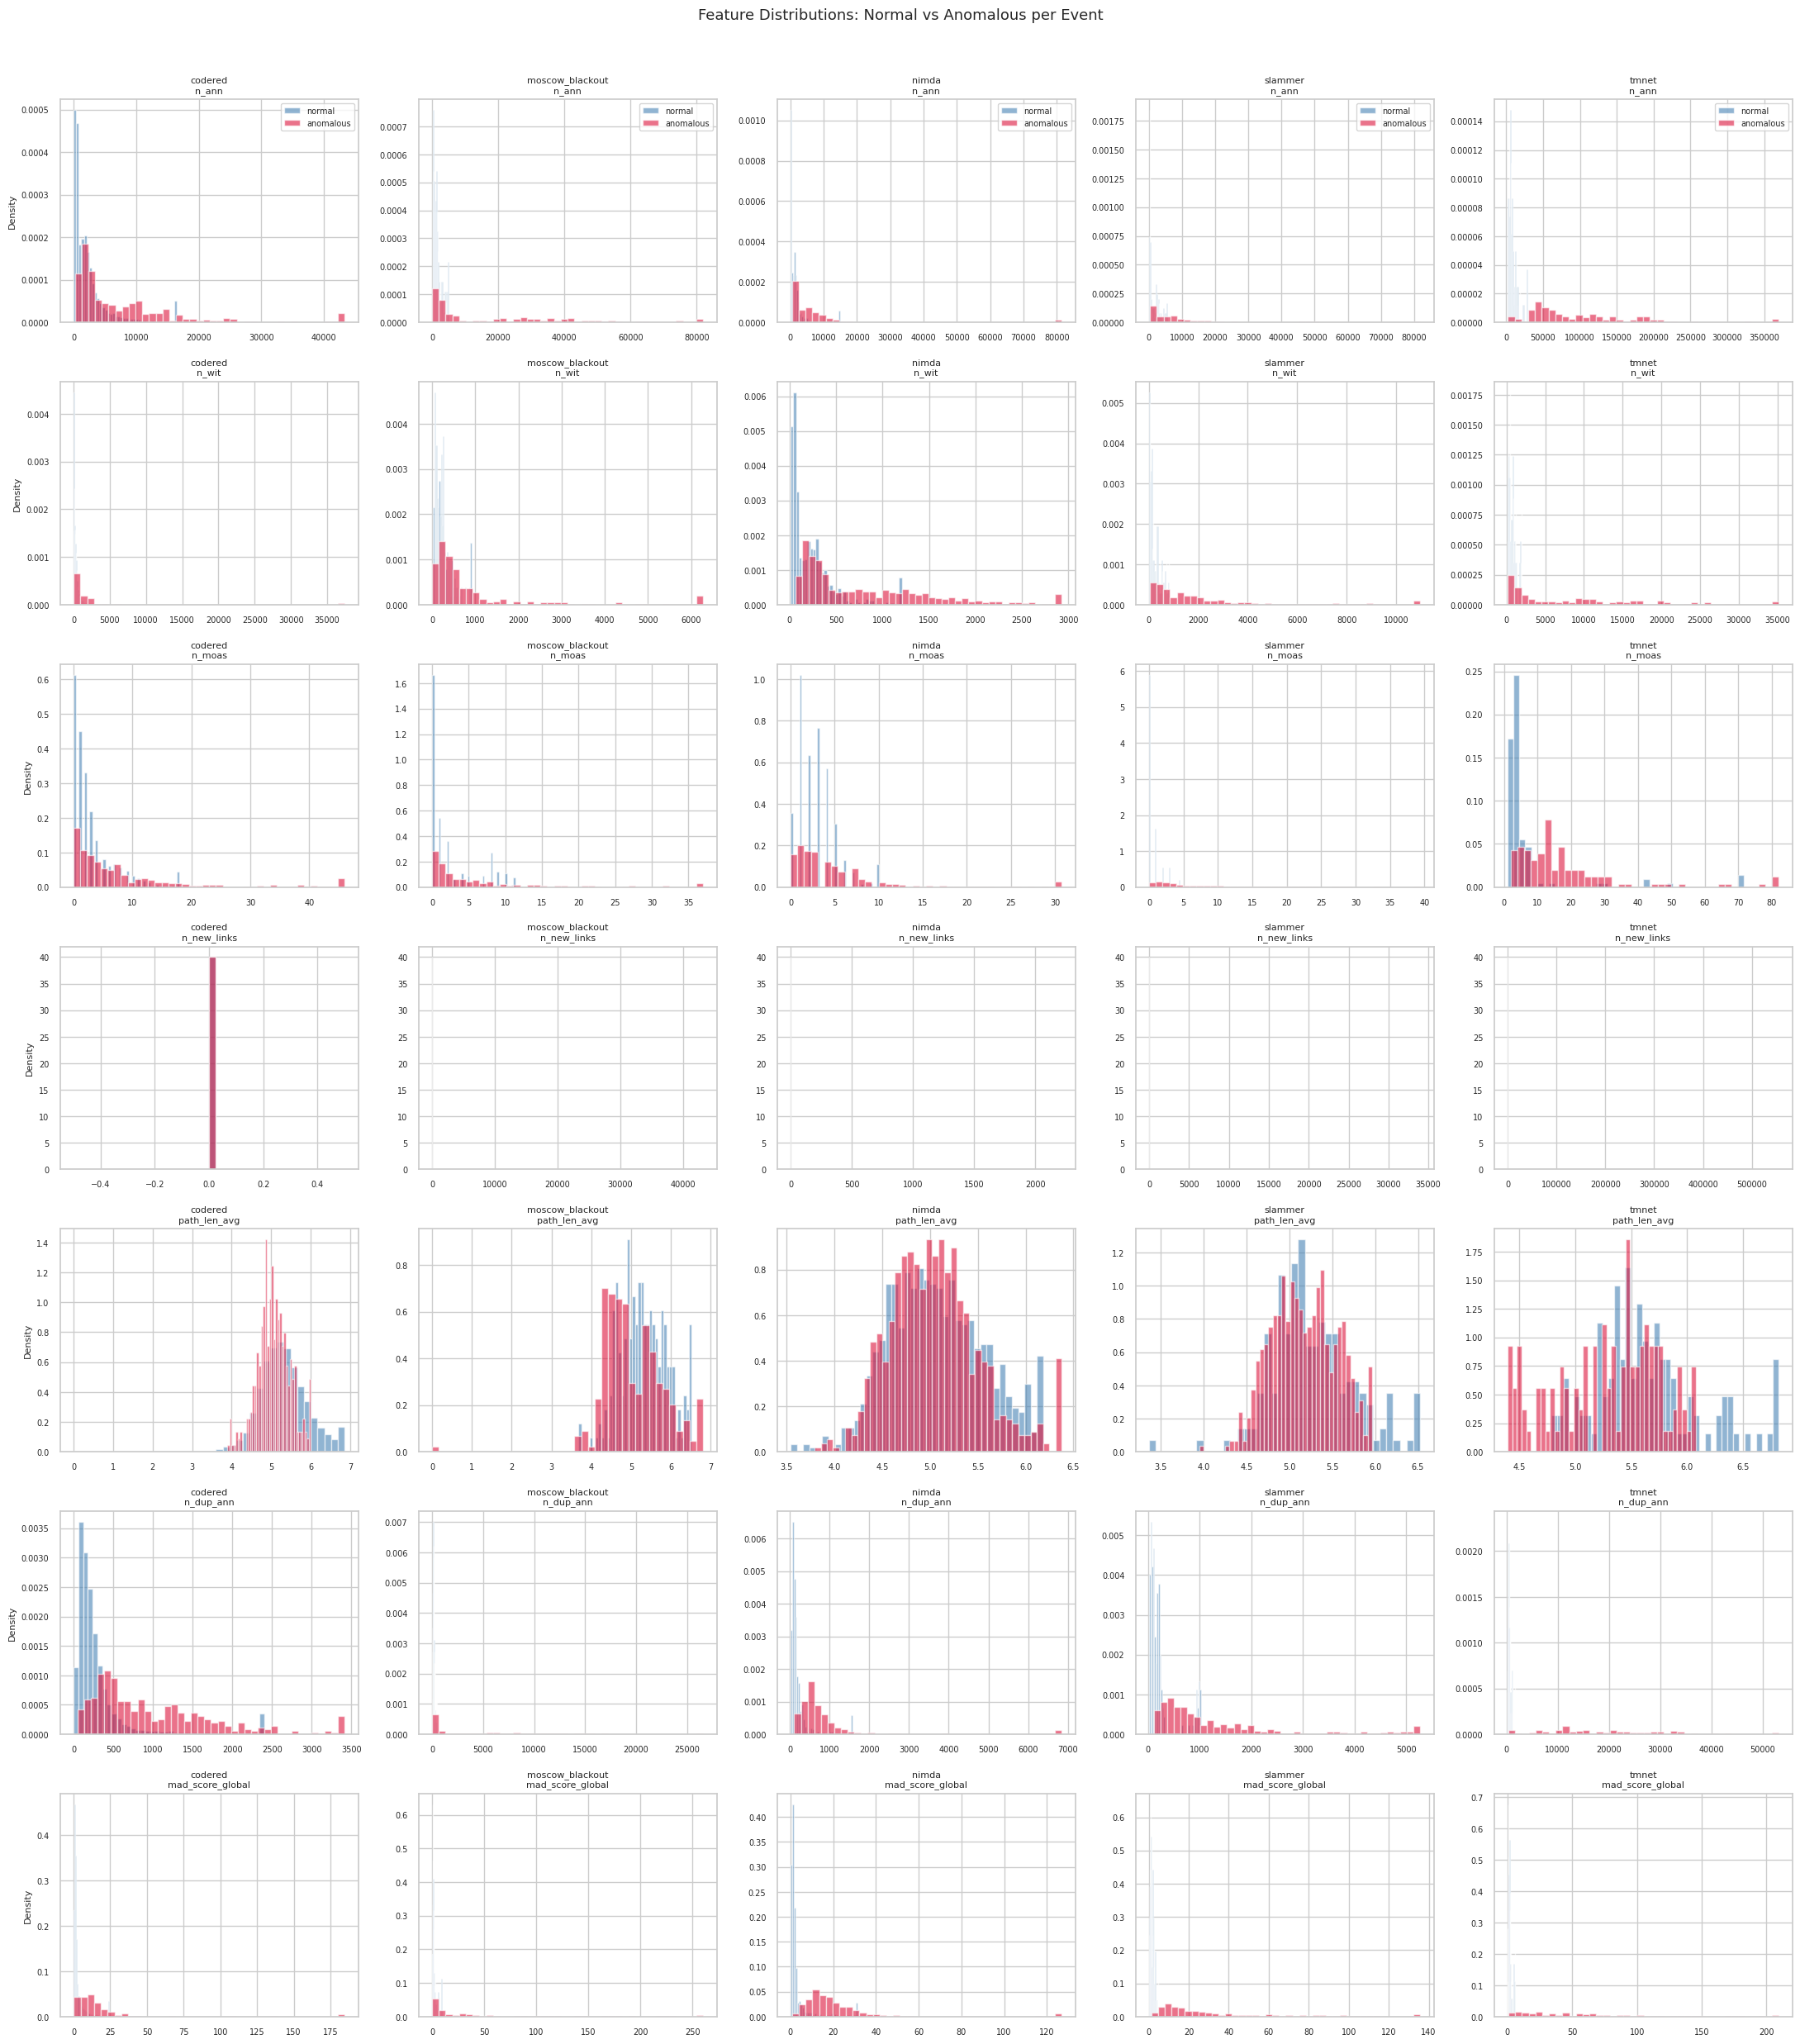

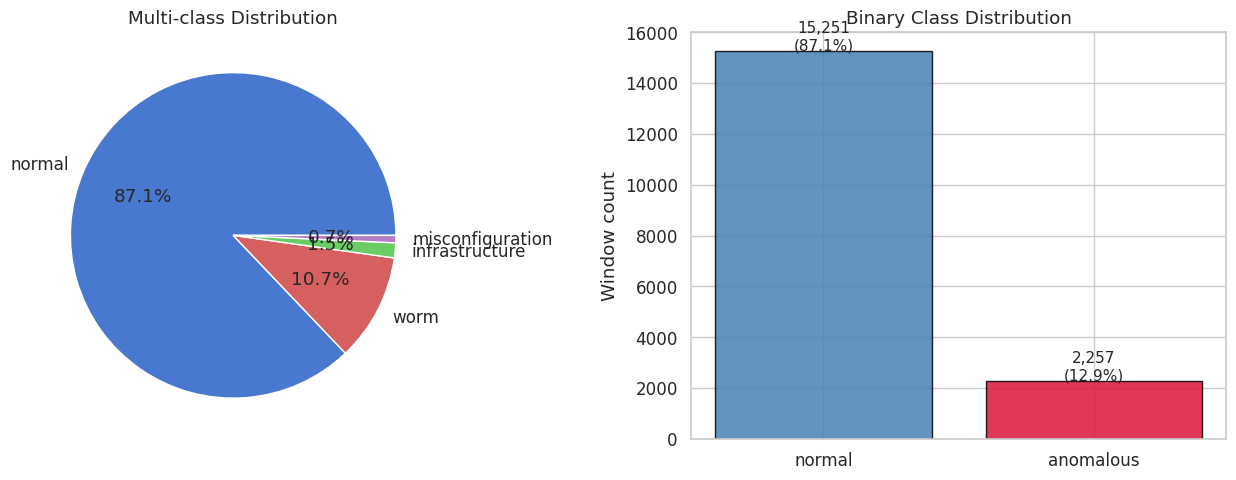

Imbalance ratio (normal:anomalous) = 6.8:1


In [5]:
EVENTS_LIST = sorted(df['event'].unique())
KEY_FEATURES = ['n_ann','n_wit','n_moas','n_new_links',
                'path_len_avg','n_dup_ann','mad_score_global']

fig, axes = plt.subplots(len(KEY_FEATURES), 5,
                          figsize=(22, 3.5 * len(KEY_FEATURES)),
                          squeeze=False)

for row, feat in enumerate(KEY_FEATURES):
    if feat not in df.columns:
        continue
    for col, ev in enumerate(EVENTS_LIST):
        ax = axes[row][col]
        sub = df[df['event'] == ev]
        for lbl, grp in sub.groupby('label_int'):
            vals = grp[feat].clip(upper=grp[feat].quantile(0.98))
            color = 'crimson' if lbl == 1 else 'steelblue'
            label = 'anomalous' if lbl == 1 else 'normal'
            ax.hist(vals, bins=40, alpha=0.6, color=color, label=label, density=True)
        ax.set_title(f'{ev}\n{feat}', fontsize=8)
        ax.tick_params(labelsize=7)
        if col == 0: ax.set_ylabel('Density', fontsize=8)
        if row == 0: ax.legend(fontsize=7)

plt.suptitle('Feature Distributions: Normal vs Anomalous per Event', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=110, bbox_inches='tight')
plt.show()

# ── Class imbalance pie ───────────────────────────────────────────────────────
counts = df['anomaly_class'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#4878CF','#D65F5F','#6ACC65','#B47CC7'])
axes[0].set_title('Multi-class Distribution')

bin_counts = df['label_int'].value_counts().rename({0:'normal',1:'anomalous'})
axes[1].bar(bin_counts.index, bin_counts.values,
            color=['steelblue','crimson'], edgecolor='black', alpha=0.85)
for i, (name, val) in enumerate(bin_counts.items()):
    axes[1].text(i, val + 50, f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=11)
axes[1].set_title('Binary Class Distribution')
axes[1].set_ylabel('Window count')
plt.tight_layout()
plt.savefig('eda_class_balance.png', dpi=110, bbox_inches='tight')
plt.show()

print(f'Imbalance ratio (normal:anomalous) = {bin_counts["normal"] / bin_counts["anomalous"]:.1f}:1')

## Cell 4 — Prepare Feature Matrices & Handle codered_normal Dominance

In [6]:
# ── Problem: codered_normal has 13,857 windows = 79% of all normal data.
# This will bias models toward codered's normal distribution.
# Fix: cap normal windows per event at 2× the anomalous count for that event.

def balance_normal_per_event(df_in, cap_ratio=4):
    """
    For each event, keep at most cap_ratio × #anomalous normal windows.
    Samples randomly but with a fixed seed for reproducibility.
    Anomalous windows are never dropped.
    """
    parts = []
    for ev in df_in['event'].unique():
        sub = df_in[df_in['event'] == ev]
        anom_df   = sub[sub['label_int'] == 1]
        normal_df = sub[sub['label_int'] == 0]
        n_anom    = len(anom_df)
        cap       = min(len(normal_df), cap_ratio * n_anom)
        normal_df = normal_df.sample(n=cap, random_state=SEED)
        print(f'  {ev:20s}: anomalous={n_anom:4d}, normal={len(normal_df):5d} '
              f'(was {len(sub[sub["label_int"]==0]):5d})')
        parts.extend([anom_df, normal_df])
    return pd.concat(parts, ignore_index=True)

print('Balancing normal windows per event (cap = 4×anomalous):')
df_balanced = balance_normal_per_event(df, cap_ratio=4)
print(f'\nOriginal : {len(df):,} windows')
print(f'Balanced : {len(df_balanced):,} windows')
print(f'\nBalanced class distribution:')
print(df_balanced['anomaly_class'].value_counts())

# ── Build arrays ──────────────────────────────────────────────────────────────
# We use df_balanced for ML / LSTM / GNN training.
# We keep df (full) for final evaluation reporting.

X_raw = df_balanced[FEATURE_COLS].values.astype(np.float32)
X_raw = np.nan_to_num(X_raw, nan=0.0, posinf=0.0, neginf=0.0)

y_bin   = df_balanced['label_int'].values.astype(int)
y_multi = df_balanced['anomaly_class'].map(MULTICLASS_MAP).fillna(0).values.astype(int)

# Standard scaler (fit on balanced training data)
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Also prepare full-dataset arrays for cross-event eval
X_full_raw    = df[FEATURE_COLS].values.astype(np.float32)
X_full_raw    = np.nan_to_num(X_full_raw)
X_full_scaled = scaler.transform(X_full_raw)   # use same scaler
y_full_bin    = df['label_int'].values.astype(int)
y_full_multi  = df['anomaly_class'].map(MULTICLASS_MAP).fillna(0).values.astype(int)

print(f'\nFeature matrix (balanced): {X_scaled.shape}')
print(f'Feature matrix (full)    : {X_full_scaled.shape}')
print(f'Binary class balance     : {np.bincount(y_bin)}')
print(f'Multi-class balance      : {np.bincount(y_multi)}')

Balancing normal windows per event (cap = 4×anomalous):
  codered             : anomalous= 426, normal= 1704 (was 13857)
  slammer             : anomalous= 580, normal=  178 (was   178)
  nimda               : anomalous= 863, normal=  862 (was   862)
  moscow_blackout     : anomalous= 260, normal=  232 (was   232)
  tmnet               : anomalous= 128, normal=  122 (was   122)

Original : 17,508 windows
Balanced : 5,355 windows

Balanced class distribution:
anomaly_class
normal              3098
worm                1869
infrastructure       260
misconfiguration     128
Name: count, dtype: int64

Feature matrix (balanced): (5355, 47)
Feature matrix (full)    : (17508, 47)
Binary class balance     : [3098 2257]
Multi-class balance      : [3098 1869  260  128]


## Cell 5 — Stage 1: MAD Pre-filter Evaluation

Best k (Combined Score): 7.0  CS=0.6367  F1=0.6795  Prec=0.5726  Rec=0.8356


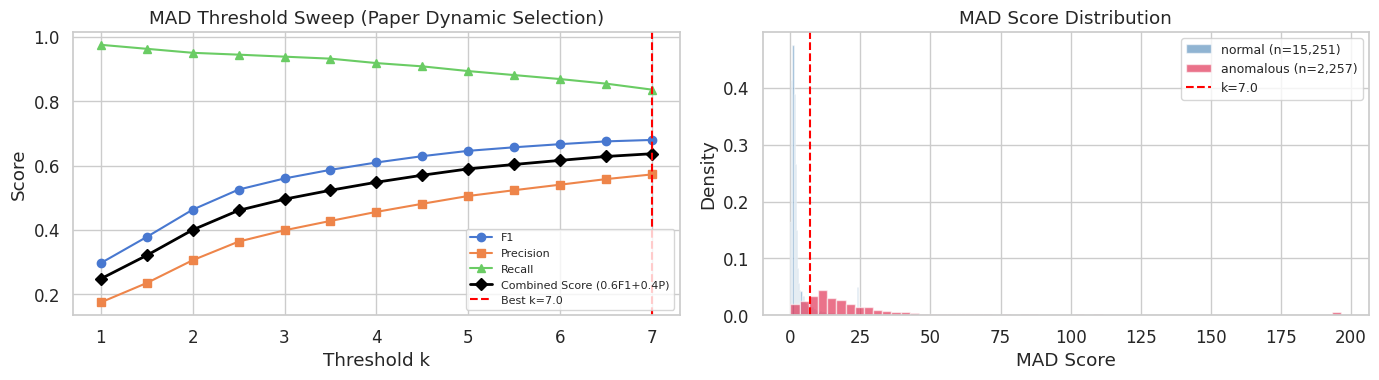


── MAD Pre-Filter (standalone) ──
              precision    recall  f1-score   support

      normal       0.97      0.91      0.94     15251
   anomalous       0.57      0.84      0.68      2257

    accuracy                           0.90     17508
   macro avg       0.77      0.87      0.81     17508
weighted avg       0.92      0.90      0.91     17508



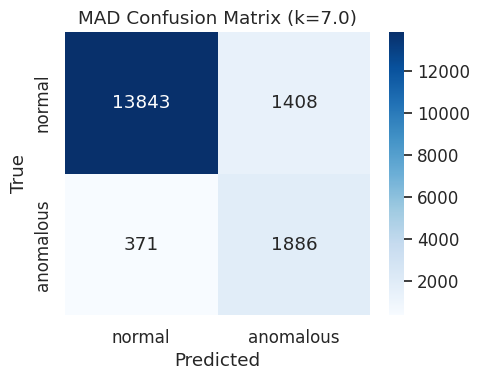

MAD flagged  : 3,294 / 17,508 (18.8%)
Data passed to Stage 2: 3,294 candidate anomalous windows


In [7]:
# ── Evaluate MAD pre-filter (k=5 from dynamic threshold in preprocessing) ─────
# Evaluated on FULL dataset (not balanced) since MAD is the first-stage filter

y_true_full = df['label_int'].values
mad_scores  = df['mad_score_global'].values

# Sweep k from 1 to 7 using paper's Combined Score = 0.6*F1 + 0.4*Precision
ks, f1s, precs, recs, css = [], [], [], [], []
for k in np.arange(1.0, 7.5, 0.5):
    y_pred_k = (mad_scores > k).astype(int)
    f1   = f1_score(y_true_full, y_pred_k, zero_division=0)
    prec = precision_score(y_true_full, y_pred_k, zero_division=0)
    rec  = recall_score(y_true_full, y_pred_k, zero_division=0)
    cs   = 0.6 * f1 + 0.4 * prec
    ks.append(k); f1s.append(f1); precs.append(prec)
    recs.append(rec); css.append(cs)

best_idx = np.argmax(css)
best_k   = ks[best_idx]
print(f'Best k (Combined Score): {best_k}  '
      f'CS={css[best_idx]:.4f}  F1={f1s[best_idx]:.4f}  '
      f'Prec={precs[best_idx]:.4f}  Rec={recs[best_idx]:.4f}')

# ── Threshold sweep plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(ks, f1s,   marker='o', label='F1')
axes[0].plot(ks, precs, marker='s', label='Precision')
axes[0].plot(ks, recs,  marker='^', label='Recall')
axes[0].plot(ks, css,   marker='D', linewidth=2, label='Combined Score (0.6F1+0.4P)', color='black')
axes[0].axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
axes[0].set_xlabel('Threshold k'); axes[0].set_ylabel('Score')
axes[0].set_title('MAD Threshold Sweep (Paper Dynamic Selection)')
axes[0].legend(fontsize=8); axes[0].grid(True)

# MAD score distribution
for lbl, name, color in [(0,'normal','steelblue'),(1,'anomalous','crimson')]:
    vals = df[df['label_int']==lbl]['mad_score_global']
    vals.clip(upper=vals.quantile(0.98)).hist(
        ax=axes[1], bins=60, alpha=0.6, color=color,
        label=f'{name} (n={len(vals):,})', density=True
    )
axes[1].axvline(best_k, color='red', linestyle='--', label=f'k={best_k}')
axes[1].set_xlabel('MAD Score'); axes[1].set_ylabel('Density')
axes[1].set_title('MAD Score Distribution')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('mad_threshold_sweep.png', dpi=110, bbox_inches='tight')
plt.show()

# ── MAD standalone classification report ──────────────────────────────────────
y_mad_pred = (mad_scores > best_k).astype(int)
print('\n── MAD Pre-Filter (standalone) ──')
print(classification_report(y_true_full, y_mad_pred,
                            target_names=CLASS_NAMES_BIN, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_true_full, y_mad_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=CLASS_NAMES_BIN, yticklabels=CLASS_NAMES_BIN)
ax.set_title(f'MAD Confusion Matrix (k={best_k})')
ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('cm_mad.png', dpi=110, bbox_inches='tight')
plt.show()

flagged = y_mad_pred.sum()
print(f'MAD flagged  : {flagged:,} / {len(y_mad_pred):,} ({flagged/len(y_mad_pred)*100:.1f}%)')
print(f'Data passed to Stage 2: {flagged:,} candidate anomalous windows')

RESULTS['MAD'] = {
    'f1_macro':  f1_score(y_true_full, y_mad_pred, average='macro', zero_division=0),
    'precision': precision_score(y_true_full, y_mad_pred, zero_division=0),
    'recall':    recall_score(y_true_full, y_mad_pred, zero_division=0),
    'note': f'k={best_k}'
}

## Cell 6 — Helper Functions

In [11]:
def safe_smote(X_tr, y_tr, random_state=SEED):
    """
    Apply BorderlineSMOTE with k_neighbors = min(5, smallest_class_size - 1).
    Falls back to returning original data if any class has < 2 samples.
    BorderlineSMOTE is better than vanilla SMOTE for BGP data because it
    focuses on borderline (hard-to-classify) minority samples.
    """
    counts = np.bincount(y_tr)
    min_count = counts[counts > 0].min()
    if min_count < 2:
        return X_tr, y_tr
    k = min(5, min_count - 1)
    try:
        sm = BorderlineSMOTE(random_state=random_state, k_neighbors=k)
        return sm.fit_resample(X_tr, y_tr)
    except Exception as e:
        print(f'    SMOTE failed ({e}), using original')
        return X_tr, y_tr


def plot_confusion(y_true, y_pred, class_names, title, fname):
    cm = confusion_matrix(y_true, y_pred)
    figsize = (max(5, len(class_names) * 1.8), max(4, len(class_names) * 1.5))
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(title); ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(fname, dpi=110, bbox_inches='tight')
    plt.show()


def cv_train_evaluate(X, y, model, model_name, class_names,
                      n_splits=5, use_smote=True):
    """
    5-fold stratified CV with optional BorderlineSMOTE per fold.
    Returns OOF predictions, OOF probabilities, per-fold F1 list.
    """
    print(f'\n── {model_name} ──')
    skf        = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    n_classes  = len(np.unique(y))
    oof_preds  = np.zeros(len(y), dtype=int)
    oof_proba  = np.zeros((len(y), n_classes))
    fold_f1s   = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y)):
        X_tr, X_va = X[tr_idx], X[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]

        if use_smote:
            X_tr, y_tr = safe_smote(X_tr, y_tr)

        model.fit(X_tr, y_tr)
        # Fix CatBoost returning shape (N,1) instead of (N,)
        preds = np.array(model.predict(X_va)).ravel().astype(int)
        oof_preds[va_idx] = preds

        if hasattr(model, 'predict_proba'):
            proba = model.predict_proba(X_va)
            # Handle case where model was trained on fewer classes
            if proba.shape[1] == n_classes:
                oof_proba[va_idx] = proba

        f1 = f1_score(y_va, preds, average='macro', zero_division=0)
        fold_f1s.append(f1)
        print(f'  Fold {fold+1}: F1-macro={f1:.4f}')

    mean_f1 = np.mean(fold_f1s)
    std_f1  = np.std(fold_f1s)
    print(f'  → Mean F1-macro = {mean_f1:.4f} ± {std_f1:.4f}')
    print(classification_report(y, oof_preds, target_names=class_names, zero_division=0))

    return oof_preds, oof_proba, fold_f1s


print('Helper functions defined ✓')

Helper functions defined ✓


## Cell 7 — Stage 2a: Classical ML Models (Binary)

XGBoost scale_pos_weight = 1.37  (neg=3098, pos=2257)

BINARY CLASSIFICATION — 5-fold CV on balanced dataset

── RandomForest ──
  Fold 1: F1-macro=0.9674
  Fold 2: F1-macro=0.9597
  Fold 3: F1-macro=0.9664
  Fold 4: F1-macro=0.9569
  Fold 5: F1-macro=0.9722
  → Mean F1-macro = 0.9645 ± 0.0055
              precision    recall  f1-score   support

      normal       0.97      0.98      0.97      3098
   anomalous       0.97      0.95      0.96      2257

    accuracy                           0.97      5355
   macro avg       0.97      0.96      0.96      5355
weighted avg       0.97      0.97      0.97      5355



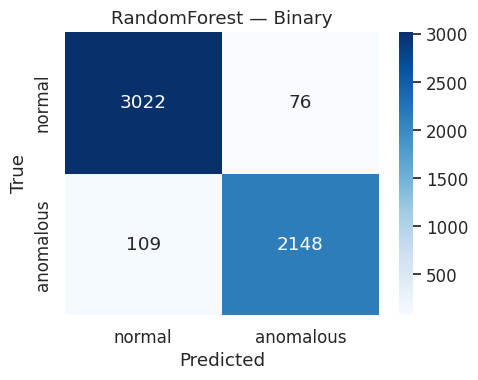


── ExtraTrees ──
  Fold 1: F1-macro=0.9494
  Fold 2: F1-macro=0.9531
  Fold 3: F1-macro=0.9703
  Fold 4: F1-macro=0.9418
  Fold 5: F1-macro=0.9580
  → Mean F1-macro = 0.9545 ± 0.0095
              precision    recall  f1-score   support

      normal       0.97      0.96      0.96      3098
   anomalous       0.94      0.95      0.95      2257

    accuracy                           0.96      5355
   macro avg       0.95      0.96      0.95      5355
weighted avg       0.96      0.96      0.96      5355



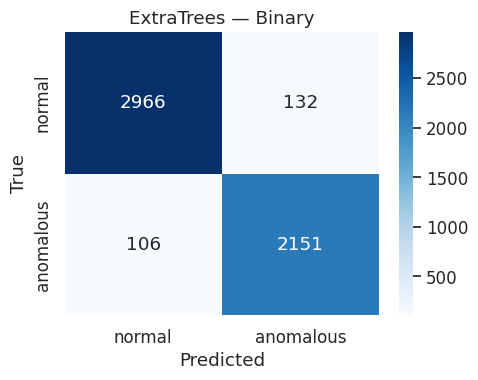


── XGBoost ──
  Fold 1: F1-macro=0.9645
  Fold 2: F1-macro=0.9655
  Fold 3: F1-macro=0.9750
  Fold 4: F1-macro=0.9647
  Fold 5: F1-macro=0.9712
  → Mean F1-macro = 0.9682 ± 0.0042
              precision    recall  f1-score   support

      normal       0.97      0.98      0.97      3098
   anomalous       0.97      0.96      0.96      2257

    accuracy                           0.97      5355
   macro avg       0.97      0.97      0.97      5355
weighted avg       0.97      0.97      0.97      5355



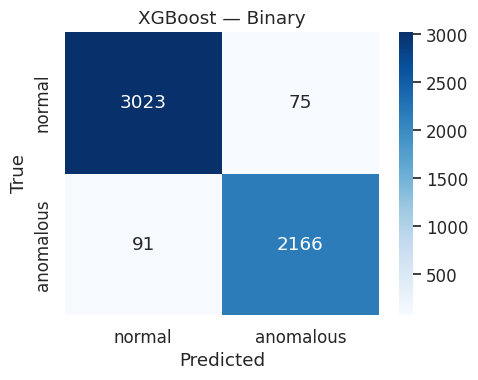


── LightGBM ──
  Fold 1: F1-macro=0.9645
  Fold 2: F1-macro=0.9655
  Fold 3: F1-macro=0.9779
  Fold 4: F1-macro=0.9665
  Fold 5: F1-macro=0.9703
  → Mean F1-macro = 0.9689 ± 0.0049
              precision    recall  f1-score   support

      normal       0.97      0.98      0.97      3098
   anomalous       0.97      0.96      0.96      2257

    accuracy                           0.97      5355
   macro avg       0.97      0.97      0.97      5355
weighted avg       0.97      0.97      0.97      5355



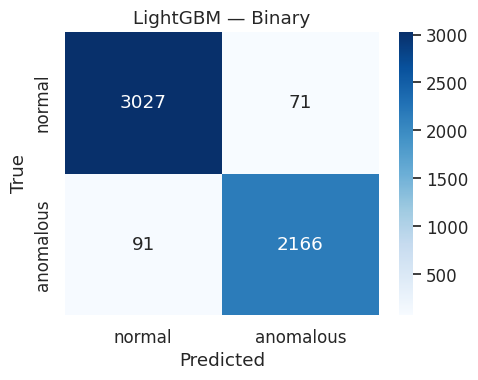


── CatBoost ──
  Fold 1: F1-macro=0.9674
  Fold 2: F1-macro=0.9617
  Fold 3: F1-macro=0.9731
  Fold 4: F1-macro=0.9608
  Fold 5: F1-macro=0.9712
  → Mean F1-macro = 0.9668 ± 0.0049
              precision    recall  f1-score   support

      normal       0.97      0.98      0.97      3098
   anomalous       0.97      0.95      0.96      2257

    accuracy                           0.97      5355
   macro avg       0.97      0.97      0.97      5355
weighted avg       0.97      0.97      0.97      5355



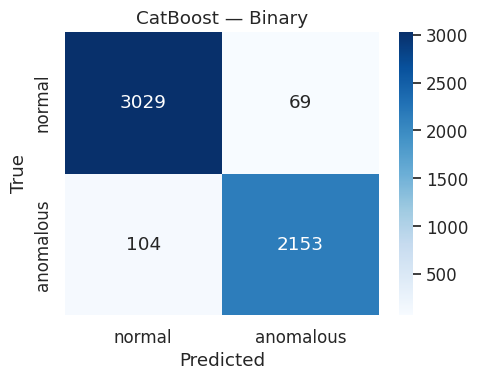


Binary ML training complete ✓


In [12]:
# ── Compute XGBoost scale_pos_weight from balanced data ───────────────────────
n_neg = (y_bin == 0).sum()
n_pos = (y_bin == 1).sum()
spw   = n_neg / n_pos
print(f'XGBoost scale_pos_weight = {spw:.2f}  (neg={n_neg}, pos={n_pos})')

# ── Model definitions ─────────────────────────────────────────────────────────
ML_MODELS_BIN = {
    'RandomForest': RandomForestClassifier(
        n_estimators=300, max_depth=None,
        class_weight='balanced', n_jobs=-1, random_state=SEED
    ),
    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=300, class_weight='balanced',
        n_jobs=-1, random_state=SEED
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        scale_pos_weight=spw,
        eval_metric='logloss',
        tree_method='hist',
        device='cuda' if torch.cuda.is_available() else 'cpu',
        random_state=SEED, verbosity=0
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05,
        is_unbalance=True,
        device='gpu' if torch.cuda.is_available() else 'cpu',
        random_state=SEED, verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=300, learning_rate=0.05,
        auto_class_weights='Balanced',
        task_type='GPU' if torch.cuda.is_available() else 'CPU',
        random_seed=SEED, verbose=0
    ),
}

# ── Train & evaluate ──────────────────────────────────────────────────────────
print('\n' + '='*60)
print('BINARY CLASSIFICATION — 5-fold CV on balanced dataset')
print('='*60)

ml_oof_bin   = {}   # name → OOF predictions
ml_proba_bin = {}   # name → OOF probabilities

for name, model in ML_MODELS_BIN.items():
    preds, proba, f1s = cv_train_evaluate(
        X_scaled, y_bin, model, name,
        class_names=CLASS_NAMES_BIN
    )
    ml_oof_bin[name]   = preds
    ml_proba_bin[name] = proba
    RESULTS[f'{name}_bin'] = {
        'f1_macro': np.mean(f1s), 'f1_std': np.std(f1s)
    }
    plot_confusion(y_bin, preds, CLASS_NAMES_BIN,
                   f'{name} — Binary', f'cm_bin_{name}.png')

print('\nBinary ML training complete ✓')

## Cell 8 — Stage 2a: Classical ML Models (Multi-class)

Multi-class label distribution in balanced data:
normal              3098
worm                1869
infrastructure       260
misconfiguration     128
Name: count, dtype: int64

MULTI-CLASS CLASSIFICATION — normal/worm/infrastructure/misconfiguration

── RandomForest ──
  Fold 1: F1-macro=0.9540
  Fold 2: F1-macro=0.9720
  Fold 3: F1-macro=0.9735
  Fold 4: F1-macro=0.9724
  Fold 5: F1-macro=0.9602
  → Mean F1-macro = 0.9664 ± 0.0079
                  precision    recall  f1-score   support

          normal       0.96      0.97      0.97      3098
            worm       0.95      0.94      0.95      1869
  infrastructure       0.97      0.98      0.98       260
misconfiguration       1.00      0.95      0.97       128

        accuracy                           0.96      5355
       macro avg       0.97      0.96      0.97      5355
    weighted avg       0.96      0.96      0.96      5355



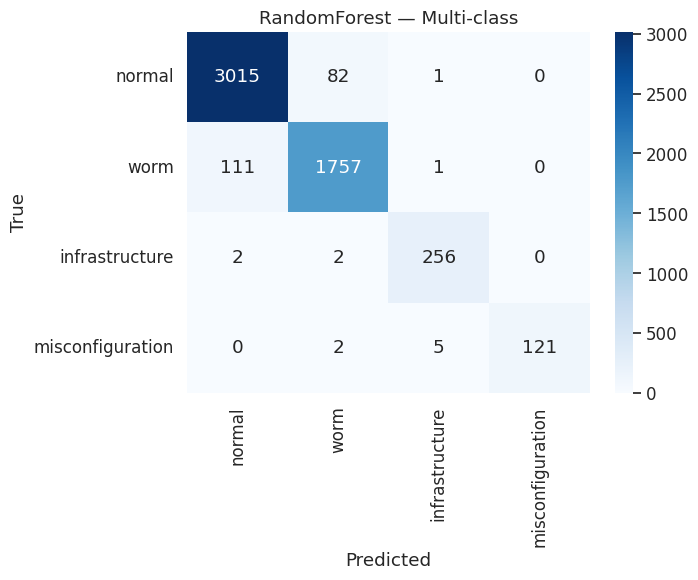


── ExtraTrees ──
  Fold 1: F1-macro=0.9460
  Fold 2: F1-macro=0.9478
  Fold 3: F1-macro=0.9528
  Fold 4: F1-macro=0.9689
  Fold 5: F1-macro=0.9532
  → Mean F1-macro = 0.9537 ± 0.0081
                  precision    recall  f1-score   support

          normal       0.96      0.96      0.96      3098
            worm       0.94      0.95      0.94      1869
  infrastructure       0.94      0.92      0.93       260
misconfiguration       1.00      0.96      0.98       128

        accuracy                           0.95      5355
       macro avg       0.96      0.95      0.95      5355
    weighted avg       0.95      0.95      0.95      5355



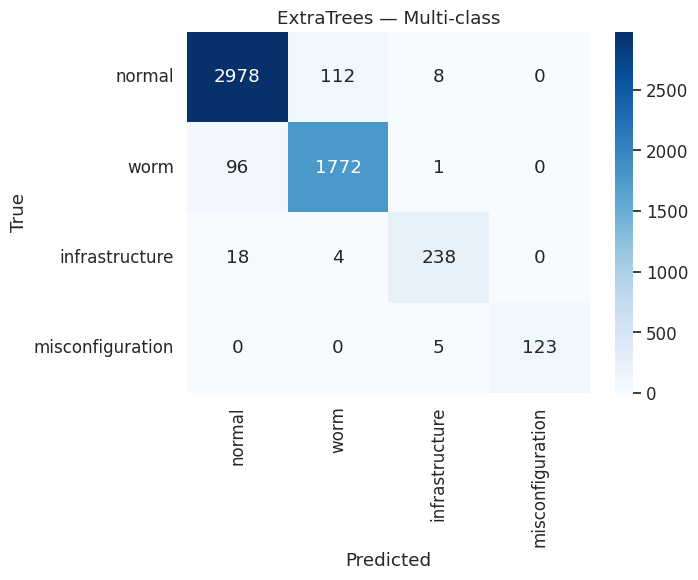


── XGBoost ──
  Fold 1: F1-macro=0.9543
  Fold 2: F1-macro=0.9812
  Fold 3: F1-macro=0.9702
  Fold 4: F1-macro=0.9769
  Fold 5: F1-macro=0.9684
  → Mean F1-macro = 0.9702 ± 0.0092
                  precision    recall  f1-score   support

          normal       0.97      0.97      0.97      3098
            worm       0.95      0.95      0.95      1869
  infrastructure       0.97      0.98      0.98       260
misconfiguration       1.00      0.97      0.98       128

        accuracy                           0.96      5355
       macro avg       0.97      0.97      0.97      5355
    weighted avg       0.96      0.96      0.96      5355



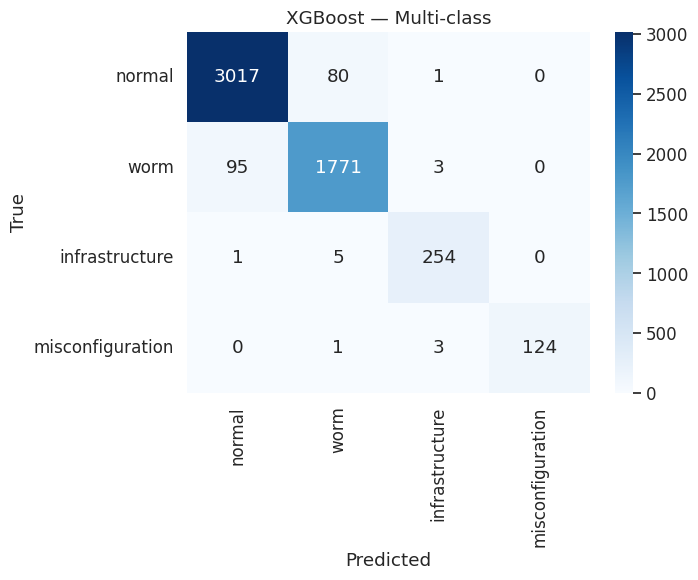


── LightGBM ──
  Fold 1: F1-macro=0.9656
  Fold 2: F1-macro=0.9753
  Fold 3: F1-macro=0.9594
  Fold 4: F1-macro=0.9750
  Fold 5: F1-macro=0.9728
  → Mean F1-macro = 0.9696 ± 0.0062
                  precision    recall  f1-score   support

          normal       0.97      0.98      0.97      3098
            worm       0.96      0.95      0.96      1869
  infrastructure       0.97      0.99      0.98       260
misconfiguration       1.00      0.95      0.97       128

        accuracy                           0.97      5355
       macro avg       0.97      0.97      0.97      5355
    weighted avg       0.97      0.97      0.97      5355



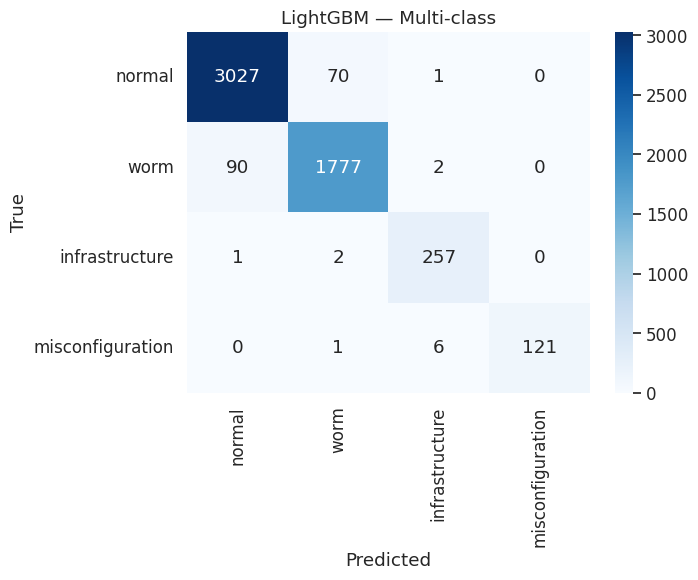


── CatBoost ──
  Fold 1: F1-macro=0.9575
  Fold 2: F1-macro=0.9737
  Fold 3: F1-macro=0.9722
  Fold 4: F1-macro=0.9714
  Fold 5: F1-macro=0.9767
  → Mean F1-macro = 0.9703 ± 0.0066
                  precision    recall  f1-score   support

          normal       0.97      0.97      0.97      3098
            worm       0.95      0.95      0.95      1869
  infrastructure       0.97      0.98      0.98       260
misconfiguration       1.00      0.97      0.98       128

        accuracy                           0.96      5355
       macro avg       0.97      0.97      0.97      5355
    weighted avg       0.96      0.96      0.96      5355



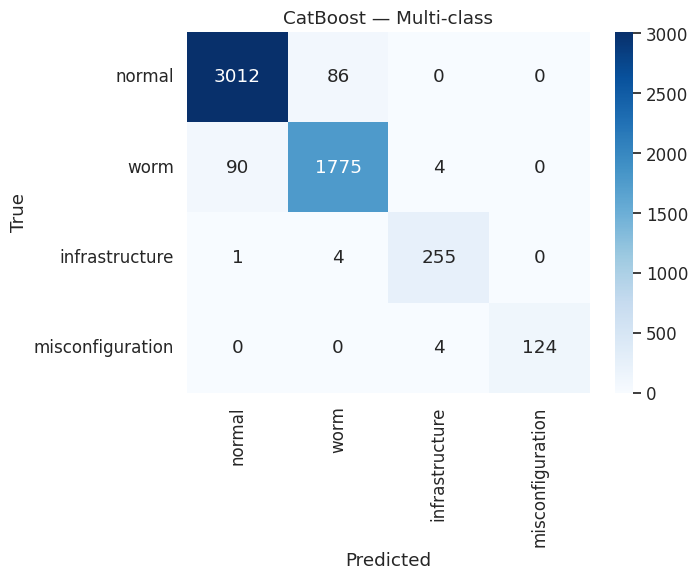


Multi-class ML training complete ✓


In [13]:
# ── Multi-class: note infrastructure(260) and misconfiguration(128) are tiny ──
# We use class_weight='balanced' everywhere to compensate.
# CatBoost and XGBoost handle it via auto-weighting.

print('Multi-class label distribution in balanced data:')
print(pd.Series(y_multi).map({v:k for k,v in MULTICLASS_MAP.items()}).value_counts())

ML_MODELS_MULTI = {
    'RandomForest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced',
        n_jobs=-1, random_state=SEED
    ),
    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=300, class_weight='balanced',
        n_jobs=-1, random_state=SEED
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        eval_metric='mlogloss',
        tree_method='hist',
        device='cuda' if torch.cuda.is_available() else 'cpu',
        random_state=SEED, verbosity=0
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05,
        class_weight='balanced',
        device='gpu' if torch.cuda.is_available() else 'cpu',
        random_state=SEED, verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=300, learning_rate=0.05,
        auto_class_weights='Balanced',
        task_type='GPU' if torch.cuda.is_available() else 'CPU',
        random_seed=SEED, verbose=0, loss_function='MultiClass'
    ),
}

print('\n' + '='*60)
print('MULTI-CLASS CLASSIFICATION — normal/worm/infrastructure/misconfiguration')
print('='*60)

ml_oof_multi   = {}
ml_proba_multi = {}

for name, model in ML_MODELS_MULTI.items():
    preds, proba, f1s = cv_train_evaluate(
        X_scaled, y_multi, model, name,
        class_names=CLASS_NAMES_MULTI
    )
    ml_oof_multi[name]   = preds
    ml_proba_multi[name] = proba
    RESULTS[f'{name}_multi'] = {
        'f1_macro': np.mean(f1s), 'f1_std': np.std(f1s)
    }
    plot_confusion(y_multi, preds, CLASS_NAMES_MULTI,
                   f'{name} — Multi-class', f'cm_multi_{name}.png')

print('\nMulti-class ML training complete ✓')

## Cell 9 — Cross-Event Generalisation Test

CROSS-EVENT GENERALISATION — Leave-One-Event-Out
  slammer             : anomalous= 580, normal=  178 (was   178)
  nimda               : anomalous= 863, normal=  862 (was   862)
  moscow_blackout     : anomalous= 260, normal=  232 (was   232)
  tmnet               : anomalous= 128, normal=  122 (was   122)
  Held-out: codered               F1=0.5014  Prec=0.2667  Rec=0.0094
              precision    recall  f1-score   support

      normal       0.97      1.00      0.98     13857
   anomalous       0.27      0.01      0.02       426

    accuracy                           0.97     14283
   macro avg       0.62      0.50      0.50     14283
weighted avg       0.95      0.97      0.96     14283



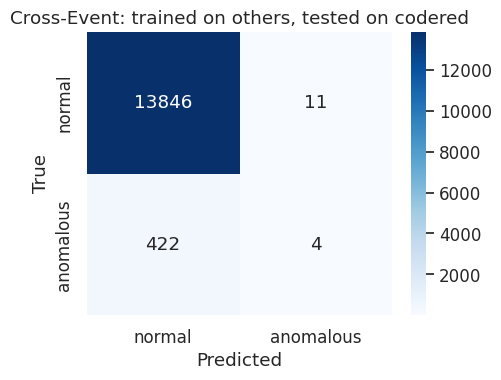

  codered             : anomalous= 426, normal= 1704 (was 13857)
  slammer             : anomalous= 580, normal=  178 (was   178)
  nimda               : anomalous= 863, normal=  862 (was   862)
  tmnet               : anomalous= 128, normal=  122 (was   122)
  Held-out: moscow_blackout       F1=0.9980  Prec=1.0000  Rec=0.9962
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00       232
   anomalous       1.00      1.00      1.00       260

    accuracy                           1.00       492
   macro avg       1.00      1.00      1.00       492
weighted avg       1.00      1.00      1.00       492



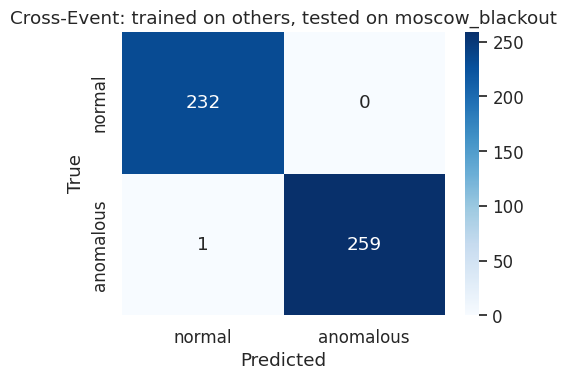

  codered             : anomalous= 426, normal= 1704 (was 13857)
  slammer             : anomalous= 580, normal=  178 (was   178)
  moscow_blackout     : anomalous= 260, normal=  232 (was   232)
  tmnet               : anomalous= 128, normal=  122 (was   122)
  Held-out: nimda                 F1=0.9849  Prec=0.9872  Rec=0.9826
              precision    recall  f1-score   support

      normal       0.98      0.99      0.98       862
   anomalous       0.99      0.98      0.98       863

    accuracy                           0.98      1725
   macro avg       0.98      0.98      0.98      1725
weighted avg       0.98      0.98      0.98      1725



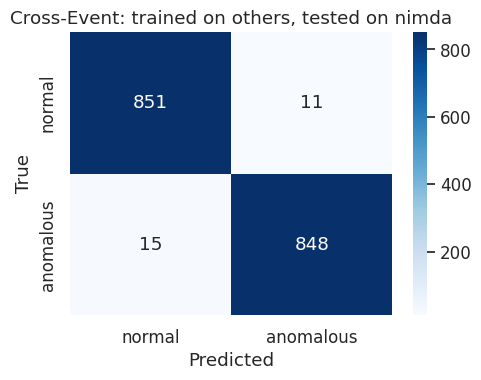

  codered             : anomalous= 426, normal= 1704 (was 13857)
  nimda               : anomalous= 863, normal=  862 (was   862)
  moscow_blackout     : anomalous= 260, normal=  232 (was   232)
  tmnet               : anomalous= 128, normal=  122 (was   122)
  Held-out: slammer               F1=1.0000  Prec=1.0000  Rec=1.0000
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00       178
   anomalous       1.00      1.00      1.00       580

    accuracy                           1.00       758
   macro avg       1.00      1.00      1.00       758
weighted avg       1.00      1.00      1.00       758



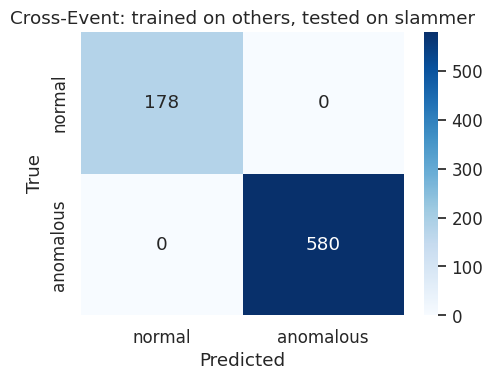

  codered             : anomalous= 426, normal= 1704 (was 13857)
  slammer             : anomalous= 580, normal=  178 (was   178)
  nimda               : anomalous= 863, normal=  862 (was   862)
  moscow_blackout     : anomalous= 260, normal=  232 (was   232)
  Held-out: tmnet                 F1=0.8901  Prec=0.8258  Rec=1.0000
              precision    recall  f1-score   support

      normal       1.00      0.78      0.88       122
   anomalous       0.83      1.00      0.90       128

    accuracy                           0.89       250
   macro avg       0.91      0.89      0.89       250
weighted avg       0.91      0.89      0.89       250



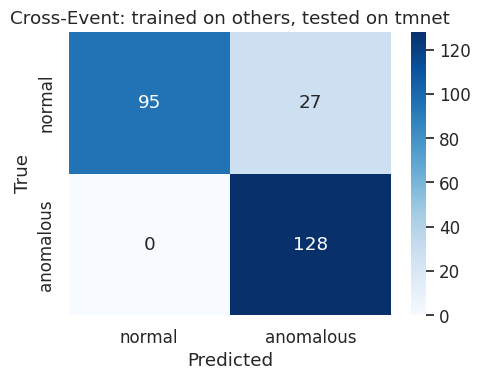

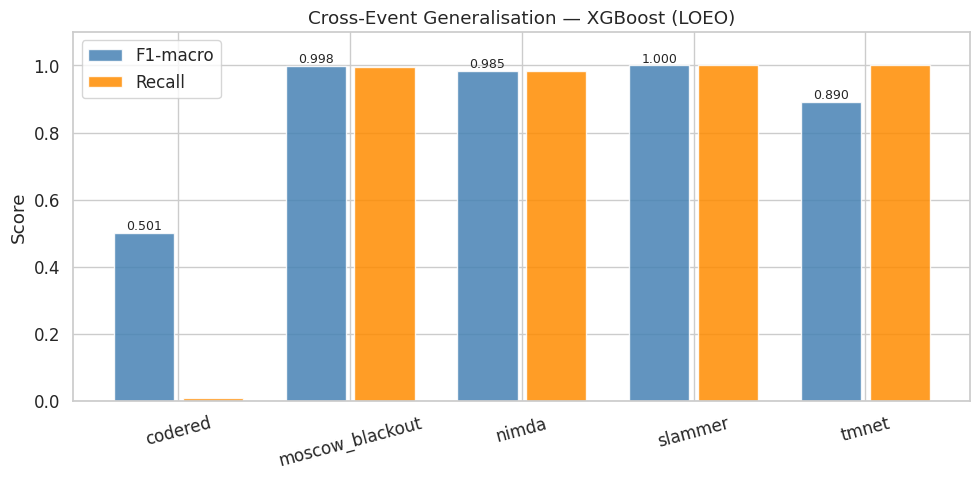

In [14]:
# ── Leave-One-Event-Out on FULL (unbalanced) dataset ─────────────────────────
# Trains on 4 events, tests on the 5th.
# Uses the full dataset to properly represent real-world class proportions.
# XGBoost is used as the primary model.

print('='*60)
print('CROSS-EVENT GENERALISATION — Leave-One-Event-Out')
print('='*60)

cross_results = {}

for held_out in EVENTS_LIST:
    mask_test  = df['event'] == held_out
    mask_train = ~mask_test

    # Use balanced version of training data
    df_train_bal = balance_normal_per_event(
        df[mask_train].copy(), cap_ratio=4
    )

    X_tr = scaler.transform(
        df_train_bal[FEATURE_COLS].values.astype(np.float32)
    )
    y_tr = df_train_bal['label_int'].values.astype(int)
    X_te = X_full_scaled[mask_test.values]
    y_te = y_full_bin[mask_test.values]

    if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
        print(f'  {held_out}: skipped (single class in split)')
        continue

    X_tr_res, y_tr_res = safe_smote(X_tr, y_tr)

    n_neg_tr = (y_tr_res == 0).sum()
    n_pos_tr = (y_tr_res == 1).sum()

    clf = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        scale_pos_weight=n_neg_tr / max(n_pos_tr, 1),
        eval_metric='logloss', tree_method='hist',
        device='cuda' if torch.cuda.is_available() else 'cpu',
        random_state=SEED, verbosity=0
    )
    clf.fit(X_tr_res, y_tr_res)
    preds = clf.predict(X_te)

    f1   = f1_score(y_te, preds, average='macro', zero_division=0)
    prec = precision_score(y_te, preds, zero_division=0)
    rec  = recall_score(y_te, preds, zero_division=0)
    cross_results[held_out] = {'f1': f1, 'precision': prec, 'recall': rec}

    print(f'  Held-out: {held_out:20s}  '
          f'F1={f1:.4f}  Prec={prec:.4f}  Rec={rec:.4f}')
    print(classification_report(y_te, preds,
          target_names=CLASS_NAMES_BIN, zero_division=0))
    plot_confusion(y_te, preds, CLASS_NAMES_BIN,
                   f'Cross-Event: trained on others, tested on {held_out}',
                   f'cm_cross_{held_out}.png')

RESULTS['cross_event_XGBoost'] = cross_results

# ── Summary bar chart ─────────────────────────────────────────────────────────
if cross_results:
    evs  = list(cross_results.keys())
    f1s  = [cross_results[e]['f1']  for e in evs]
    recs = [cross_results[e]['recall'] for e in evs]

    x = np.arange(len(evs))
    fig, ax = plt.subplots(figsize=(10, 5))
    bars1 = ax.bar(x - 0.2, f1s,  0.35, label='F1-macro',  color='steelblue', alpha=0.85)
    bars2 = ax.bar(x + 0.2, recs, 0.35, label='Recall',    color='darkorange', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(evs, rotation=15)
    ax.set_ylabel('Score'); ax.set_ylim(0, 1.1)
    ax.set_title('Cross-Event Generalisation — XGBoost (LOEO)')
    ax.legend()
    for bar in bars1:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{bar.get_height():.3f}', ha='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('cross_event_generalisation.png', dpi=110, bbox_inches='tight')
    plt.show()

## Cell 10 — Stage 2b: Bi-LSTM with Attention

In [15]:
# ── Build sequences: sorted within each (collector, event, label) group ───────
# SEQ_LEN=20 windows × 3 min = 1 hour of context per sample
SEQ_LEN = 20
STRIDE  = 5    # step between windows (avoids excessive overlap)

def make_sequences(df_in, feature_cols, seq_len, stride, y_col='label_int'):
    seqs, labels = [], []
    groups = df_in.groupby(['collector', 'event', y_col])
    for (_, _, lbl), grp in groups:
        grp = grp.sort_values('window_start')
        X_g = grp[feature_cols].values.astype(np.float32)
        X_g = np.nan_to_num(X_g)
        n   = len(X_g)
        if n < seq_len:
            continue
        for i in range(0, n - seq_len + 1, stride):
            seqs.append(X_g[i : i + seq_len])
            labels.append(int(lbl))
    return np.array(seqs, dtype=np.float32), np.array(labels, dtype=np.int64)

# Use balanced data for sequence building
X_seq_raw, y_seq = make_sequences(df_balanced, FEATURE_COLS, SEQ_LEN, STRIDE)
print(f'Sequence dataset: X={X_seq_raw.shape}, y={y_seq.shape}')
print(f'Class balance   : {np.bincount(y_seq)}')

# Scale: reshape → scale → reshape back
orig_shape    = X_seq_raw.shape
X_seq_flat    = X_seq_raw.reshape(-1, orig_shape[-1])
X_seq_scaled  = scaler.transform(X_seq_flat).reshape(orig_shape)

X_seq_t = torch.tensor(X_seq_scaled, dtype=torch.float32)
y_seq_t = torch.tensor(y_seq,        dtype=torch.long)
print('Sequences ready ✓')

Sequence dataset: X=(1004, 20, 47), y=(1004,)
Class balance   : [586 418]
Sequences ready ✓


Training Bi-LSTM ...

── Bi-LSTM ──
  Fold 1: best F1=1.0000
  Fold 2: best F1=0.9898
  Fold 3: best F1=0.9949
  Fold 4: best F1=0.9898
  Fold 5: best F1=0.9846
  → Mean F1-macro = 0.9918 ± 0.0052
              precision    recall  f1-score   support

      normal       1.00      0.95      0.98       586
   anomalous       0.94      1.00      0.97       418

    accuracy                           0.97      1004
   macro avg       0.97      0.98      0.97      1004
weighted avg       0.97      0.97      0.97      1004



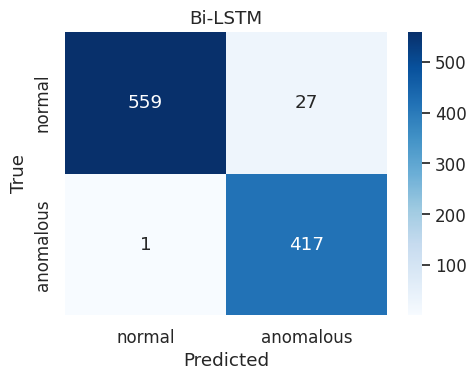


Training Bi-GRU ...

── Bi-GRU ──
  Fold 1: best F1=0.9846
  Fold 2: best F1=0.9949
  Fold 3: best F1=0.9898
  Fold 4: best F1=0.9847
  Fold 5: best F1=0.9897
  → Mean F1-macro = 0.9888 ± 0.0038
              precision    recall  f1-score   support

      normal       0.99      0.99      0.99       586
   anomalous       0.98      0.98      0.98       418

    accuracy                           0.99      1004
   macro avg       0.98      0.98      0.98      1004
weighted avg       0.99      0.99      0.99      1004



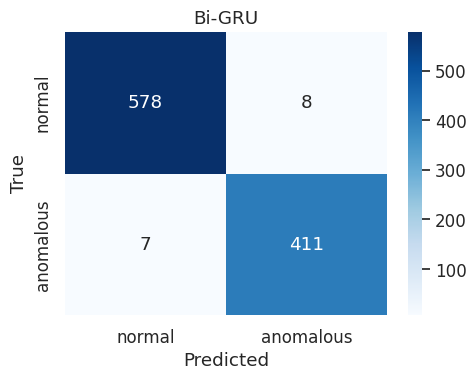


RNN models complete ✓


In [16]:
class BGPBiLSTM(nn.Module):
    """
    Bidirectional LSTM with scaled dot-product attention pooling.
    Input : (batch, seq_len, n_features)
    Output: (batch, n_classes)
    """
    def __init__(self, input_dim, hidden=128, n_layers=2,
                 n_classes=2, dropout=0.35):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden, n_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.attn_w  = nn.Linear(hidden * 2, 1, bias=False)
        self.dropout = nn.Dropout(dropout)
        self.bn      = nn.BatchNorm1d(hidden * 2)
        self.fc1     = nn.Linear(hidden * 2, 64)
        self.fc2     = nn.Linear(64, n_classes)

    def forward(self, x):
        out, _ = self.lstm(x)                          # (B, T, 2H)
        attn   = torch.softmax(self.attn_w(out), dim=1) # (B, T, 1)
        ctx    = (attn * out).sum(dim=1)               # (B, 2H)
        ctx    = self.bn(ctx)
        ctx    = self.dropout(ctx)
        h      = F.relu(self.fc1(ctx))
        h      = self.dropout(h)
        return self.fc2(h)


class BGPGRU(nn.Module):
    """GRU variant — same interface as BGPBiLSTM."""
    def __init__(self, input_dim, hidden=128, n_layers=2,
                 n_classes=2, dropout=0.35):
        super().__init__()
        self.gru = nn.GRU(
            input_dim, hidden, n_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.attn_w  = nn.Linear(hidden * 2, 1, bias=False)
        self.dropout = nn.Dropout(dropout)
        self.bn      = nn.BatchNorm1d(hidden * 2)
        self.fc1     = nn.Linear(hidden * 2, 64)
        self.fc2     = nn.Linear(64, n_classes)

    def forward(self, x):
        out, _ = self.gru(x)
        attn   = torch.softmax(self.attn_w(out), dim=1)
        ctx    = (attn * out).sum(dim=1)
        ctx    = self.bn(ctx)
        ctx    = self.dropout(ctx)
        h      = F.relu(self.fc1(ctx))
        h      = self.dropout(h)
        return self.fc2(h)


def train_rnn_model(X_t, y_t, ModelClass, model_name,
                    n_classes=2, n_epochs=50, lr=1e-3,
                    batch_size=64, patience=8):
    """Generic trainer for LSTM / GRU with 5-fold CV and early stopping."""
    input_dim = X_t.shape[2]
    skf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    all_preds = np.zeros(len(y_t), dtype=int)
    all_proba = np.zeros((len(y_t), n_classes))
    fold_f1s  = []
    best_state = None; best_global = -1

    print(f'\n── {model_name} ──')

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_t.numpy(), y_t.numpy())):
        X_tr = X_t[tr_idx].to(DEVICE)
        y_tr = y_t[tr_idx].to(DEVICE)
        X_va = X_t[va_idx].to(DEVICE)
        y_va = y_t[va_idx]

        counts  = np.bincount(y_t[tr_idx].numpy(), minlength=n_classes)
        weights = torch.tensor(1.0 / np.maximum(counts, 1),
                               dtype=torch.float32).to(DEVICE)

        model     = ModelClass(input_dim, n_classes=n_classes).to(DEVICE)
        opt       = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        sched     = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
        criterion = nn.CrossEntropyLoss(weight=weights)

        loader  = DataLoader(TensorDataset(X_tr, y_tr),
                             batch_size=batch_size, shuffle=True)

        best_f1 = -1; pat = 0
        for epoch in range(n_epochs):
            model.train()
            for xb, yb in loader:
                opt.zero_grad()
                loss = criterion(model(xb), yb)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
            sched.step()

            model.eval()
            with torch.no_grad():
                preds_e = model(X_va).argmax(dim=1).cpu().numpy()
            f1 = f1_score(y_va.numpy(), preds_e, average='macro', zero_division=0)

            if f1 > best_f1:
                best_f1 = f1; pat = 0
                if f1 > best_global:
                    best_global = f1
                    best_state  = {k: v.cpu().clone()
                                   for k, v in model.state_dict().items()}
            else:
                pat += 1
                if pat >= patience: break

        # Final fold evaluation
        model.eval()
        with torch.no_grad():
            logits = model(X_va)
        preds_f = logits.argmax(dim=1).cpu().numpy()
        proba_f = torch.softmax(logits, dim=1).cpu().numpy()
        all_preds[va_idx] = preds_f
        all_proba[va_idx] = proba_f
        fold_f1s.append(best_f1)
        print(f'  Fold {fold+1}: best F1={best_f1:.4f}')

    mean_f1 = np.mean(fold_f1s)
    print(f'  → Mean F1-macro = {mean_f1:.4f} ± {np.std(fold_f1s):.4f}')
    print(classification_report(y_t.numpy(), all_preds,
          target_names=CLASS_NAMES_BIN, zero_division=0))
    return all_preds, all_proba, fold_f1s, best_state


# ── Train LSTM ────────────────────────────────────────────────────────────────
print('Training Bi-LSTM ...')
lstm_preds, lstm_proba, lstm_f1s, lstm_state = train_rnn_model(
    X_seq_t, y_seq_t, BGPBiLSTM, 'Bi-LSTM'
)
plot_confusion(y_seq, lstm_preds, CLASS_NAMES_BIN, 'Bi-LSTM', 'cm_lstm.png')
RESULTS['BiLSTM_bin'] = {'f1_macro': np.mean(lstm_f1s), 'f1_std': np.std(lstm_f1s)}
if lstm_state: torch.save(lstm_state, 'bgp_lstm.pt')

# ── Train GRU ─────────────────────────────────────────────────────────────────
print('\nTraining Bi-GRU ...')
gru_preds, gru_proba, gru_f1s, gru_state = train_rnn_model(
    X_seq_t, y_seq_t, BGPGRU, 'Bi-GRU'
)
plot_confusion(y_seq, gru_preds, CLASS_NAMES_BIN, 'Bi-GRU', 'cm_gru.png')
RESULTS['BiGRU_bin'] = {'f1_macro': np.mean(gru_f1s), 'f1_std': np.std(gru_f1s)}
if gru_state: torch.save(gru_state, 'bgp_gru.pt')

print('\nRNN models complete ✓')

## Cell 11 — Stage 2c: GraphSAGE GNN

Building graph dataset from balanced data ...
Graphs : 1044
Balance: [606 438]

── GraphSAGE ──
  Fold 1: best F1=0.9273
  Fold 2: best F1=0.9368
  Fold 3: best F1=0.9172
  Fold 4: best F1=0.9562
  Fold 5: best F1=0.8840
  → Mean F1-macro = 0.9243 ± 0.0239
              precision    recall  f1-score   support

      normal       0.83      0.28      0.42       606
   anomalous       0.48      0.92      0.63       438

    accuracy                           0.55      1044
   macro avg       0.65      0.60      0.53      1044
weighted avg       0.68      0.55      0.51      1044



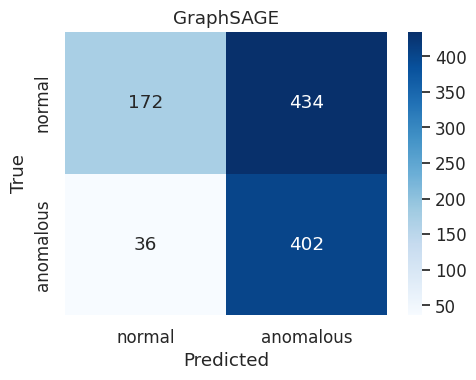


GNN complete ✓


In [17]:
# ── Build chain graphs from consecutive windows ───────────────────────────────
# Group size = 10 windows (30 min). Each node = one window.
# Edges: bidirectional chain t↔t+1.
# Label = majority label in group.

GROUP_SIZE = 10
STRIDE_GNN = GROUP_SIZE // 2   # 50% overlap between groups

def build_graph_dataset(df_in, feature_cols, group_size, stride, y_col='label_int'):
    graphs = []
    groups = df_in.sort_values('window_start').groupby(
        ['collector', 'event', y_col]
    )
    for (_, _, lbl), grp in groups:
        grp = grp.reset_index(drop=True)
        X_g = np.nan_to_num(grp[feature_cols].values.astype(np.float32))
        n   = len(X_g)
        if n < group_size:
            continue
        for start in range(0, n - group_size + 1, stride):
            chunk = X_g[start : start + group_size]
            sz    = len(chunk)
            # Bidirectional chain edges
            src = list(range(sz-1)) + list(range(1, sz))
            dst = list(range(1, sz)) + list(range(sz-1))
            graphs.append(Data(
                x          = torch.tensor(chunk,    dtype=torch.float32),
                edge_index = torch.tensor([src,dst], dtype=torch.long),
                y          = torch.tensor([int(lbl)],dtype=torch.long)
            ))
    return graphs


print('Building graph dataset from balanced data ...')
graph_data = build_graph_dataset(
    df_balanced, FEATURE_COLS, GROUP_SIZE, STRIDE_GNN
)
g_labels = np.array([g.y.item() for g in graph_data])
print(f'Graphs : {len(graph_data)}')
print(f'Balance: {np.bincount(g_labels)}')

# ── GraphSAGE model ───────────────────────────────────────────────────────────
class BGPGNN(nn.Module):
    def __init__(self, in_channels, hidden=128, n_classes=2, dropout=0.35):
        super().__init__()
        self.conv1   = SAGEConv(in_channels, hidden)
        self.conv2   = SAGEConv(hidden, hidden)
        self.conv3   = SAGEConv(hidden, hidden // 2)
        self.bn1     = nn.BatchNorm1d(hidden)
        self.bn2     = nn.BatchNorm1d(hidden)
        self.dropout = nn.Dropout(dropout)
        self.fc1     = nn.Linear(hidden // 2, 64)
        self.fc2     = nn.Linear(64, n_classes)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch)         # graph-level pooling
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


def train_gnn(graph_data, n_classes=2, n_epochs=60,
              lr=5e-4, batch_size=32, patience=10):
    labels   = np.array([g.y.item() for g in graph_data])
    in_ch    = graph_data[0].x.shape[1]
    skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    all_pred = np.zeros(len(graph_data), dtype=int)
    all_prob = np.zeros((len(graph_data), n_classes))
    fold_f1s = []
    best_state = None; best_global = -1

    print('\n── GraphSAGE ──')
    for fold, (tr_idx, va_idx) in enumerate(skf.split(np.arange(len(graph_data)), labels)):
        tr_g = [graph_data[i] for i in tr_idx]
        va_g = [graph_data[i] for i in va_idx]
        y_tr = labels[tr_idx]

        counts  = np.bincount(y_tr, minlength=n_classes)
        weights = torch.tensor(1.0/np.maximum(counts,1), dtype=torch.float32).to(DEVICE)

        tr_loader = PyGDataLoader(tr_g, batch_size=batch_size, shuffle=True)
        va_loader = PyGDataLoader(va_g, batch_size=batch_size)

        model     = BGPGNN(in_ch, n_classes=n_classes).to(DEVICE)
        opt       = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        sched     = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
        criterion = nn.CrossEntropyLoss(weight=weights)

        best_f1 = -1; pat = 0
        for epoch in range(n_epochs):
            model.train()
            for bg in tr_loader:
                bg = bg.to(DEVICE)
                opt.zero_grad()
                loss = criterion(model(bg.x, bg.edge_index, bg.batch), bg.y)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
            sched.step()

            model.eval()
            vp = []
            with torch.no_grad():
                for bg in va_loader:
                    bg = bg.to(DEVICE)
                    vp.extend(model(bg.x,bg.edge_index,bg.batch)
                               .argmax(dim=1).cpu().numpy())
            f1 = f1_score(labels[va_idx], vp, average='macro', zero_division=0)
            if f1 > best_f1:
                best_f1 = f1; pat = 0
                if f1 > best_global:
                    best_global = f1
                    best_state  = {k: v.cpu().clone() for k,v in model.state_dict().items()}
            else:
                pat += 1
                if pat >= patience: break

        # Final preds
        model.eval()
        vp, vprob = [], []
        with torch.no_grad():
            for bg in va_loader:
                bg = bg.to(DEVICE)
                out = model(bg.x, bg.edge_index, bg.batch)
                vp.extend(out.argmax(dim=1).cpu().numpy())
                vprob.extend(torch.softmax(out,dim=1).cpu().numpy())
        all_pred[va_idx] = vp
        all_prob[va_idx] = vprob
        fold_f1s.append(best_f1)
        print(f'  Fold {fold+1}: best F1={best_f1:.4f}')

    print(f'  → Mean F1-macro = {np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}')
    print(classification_report(labels, all_pred,
          target_names=CLASS_NAMES_BIN, zero_division=0))
    return all_pred, all_prob, fold_f1s, best_state


gnn_preds, gnn_proba, gnn_f1s, gnn_state = train_gnn(graph_data)
plot_confusion(g_labels, gnn_preds, CLASS_NAMES_BIN, 'GraphSAGE', 'cm_gnn.png')
RESULTS['GraphSAGE_bin'] = {'f1_macro': np.mean(gnn_f1s), 'f1_std': np.std(gnn_f1s)}
if gnn_state: torch.save(gnn_state, 'bgp_gnn.pt')
print('\nGNN complete ✓')

## Cell 12 — Stage 3: Stacking Ensemble

Meta-feature matrix: (5355, 11)
Meta features: ['RandomForest_p0', 'RandomForest_p1', 'ExtraTrees_p0', 'ExtraTrees_p1', 'XGBoost_p0', 'XGBoost_p1', 'LightGBM_p0', 'LightGBM_p1', 'CatBoost_p0', 'CatBoost_p1', 'mad_score']

── Stacking Ensemble (LR meta-learner) ──
  Fold 1: F1-macro=0.9693
  Fold 2: F1-macro=0.9665
  Fold 3: F1-macro=0.9693
  Fold 4: F1-macro=0.9599
  Fold 5: F1-macro=0.9722
  → Mean F1-macro = 0.9674 ± 0.0042
              precision    recall  f1-score   support

      normal       0.97      0.97      0.97      3098
   anomalous       0.96      0.96      0.96      2257

    accuracy                           0.97      5355
   macro avg       0.97      0.97      0.97      5355
weighted avg       0.97      0.97      0.97      5355



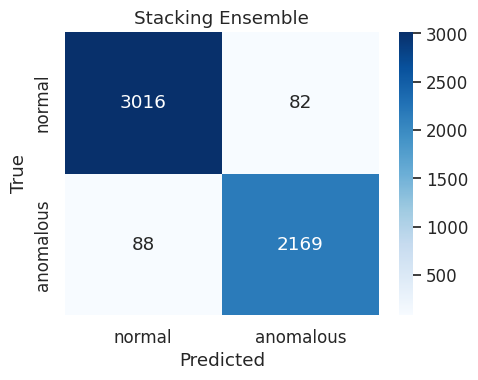

In [18]:
# ── Stack OOF probabilities from all ML models (window-level) ─────────────────
# LSTM/GRU/GNN operate on sequences/graphs (different index length),
# so stacking is done only on the shared window-level ML OOF predictions.

meta_parts = []
for name in ML_MODELS_BIN.keys():
    if name in ml_proba_bin and ml_proba_bin[name].shape[1] == 2:
        meta_parts.append(
            pd.DataFrame(ml_proba_bin[name],
                         columns=[f'{name}_p0', f'{name}_p1'])
        )

# Add MAD score as a meta-feature
df_bal_reset = df_balanced.reset_index(drop=True)
meta_parts.append(
    pd.DataFrame({'mad_score': df_bal_reset['mad_score_global'].values})
)

df_meta  = pd.concat(meta_parts, axis=1)
X_meta   = df_meta.values
y_meta   = y_bin

meta_sc  = StandardScaler()
X_meta_s = meta_sc.fit_transform(X_meta)

print(f'Meta-feature matrix: {X_meta_s.shape}')
print(f'Meta features: {df_meta.columns.tolist()}')

# ── Logistic Regression meta-learner (interpretable) ─────────────────────────
skf_meta   = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
meta_preds = np.zeros(len(y_meta), dtype=int)
meta_proba = np.zeros((len(y_meta), 2))
meta_f1s   = []

print('\n── Stacking Ensemble (LR meta-learner) ──')
for fold, (tr, va) in enumerate(skf_meta.split(X_meta_s, y_meta)):
    lr_meta = LogisticRegression(
        C=1.0, class_weight='balanced',
        max_iter=1000, random_state=SEED
    )
    lr_meta.fit(X_meta_s[tr], y_meta[tr])
    meta_preds[va]  = lr_meta.predict(X_meta_s[va])
    meta_proba[va]  = lr_meta.predict_proba(X_meta_s[va])
    f1 = f1_score(y_meta[va], meta_preds[va], average='macro', zero_division=0)
    meta_f1s.append(f1)
    print(f'  Fold {fold+1}: F1-macro={f1:.4f}')

print(f'  → Mean F1-macro = {np.mean(meta_f1s):.4f} ± {np.std(meta_f1s):.4f}')
print(classification_report(y_meta, meta_preds,
      target_names=CLASS_NAMES_BIN, zero_division=0))
plot_confusion(y_meta, meta_preds, CLASS_NAMES_BIN,
               'Stacking Ensemble', 'cm_stacking.png')
RESULTS['Stacking_bin'] = {
    'f1_macro': np.mean(meta_f1s), 'f1_std': np.std(meta_f1s)
}

## Cell 13 — SHAP Explainability

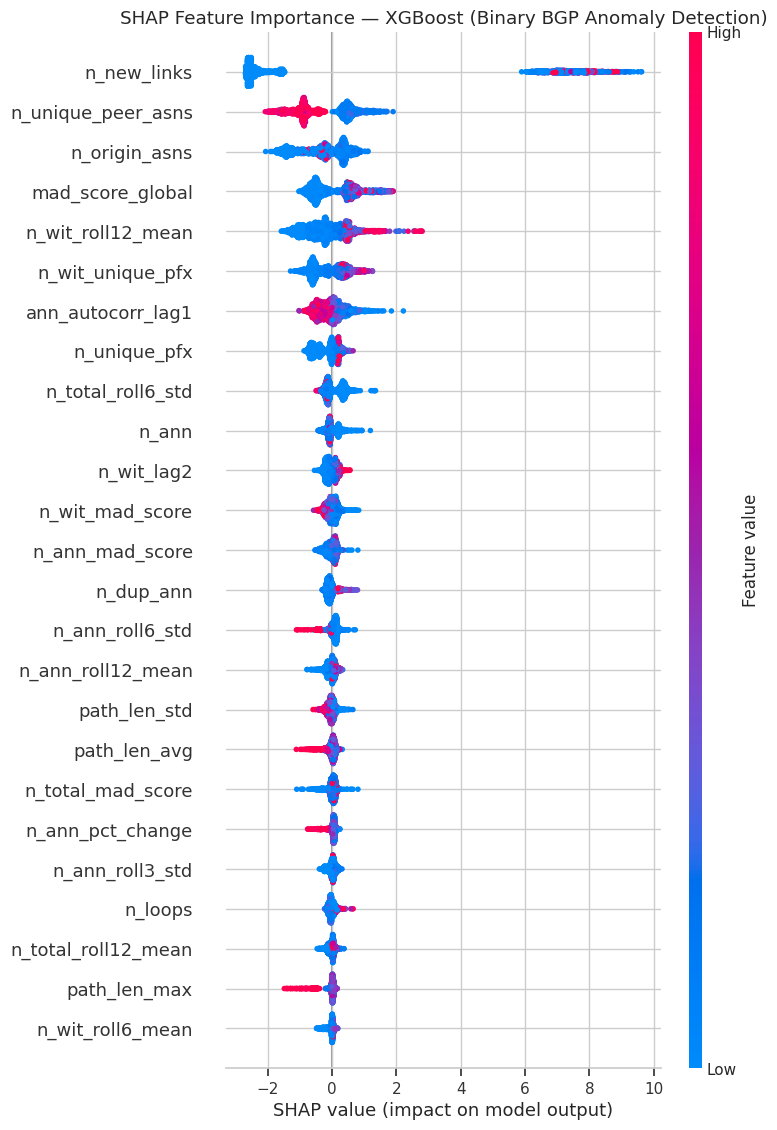

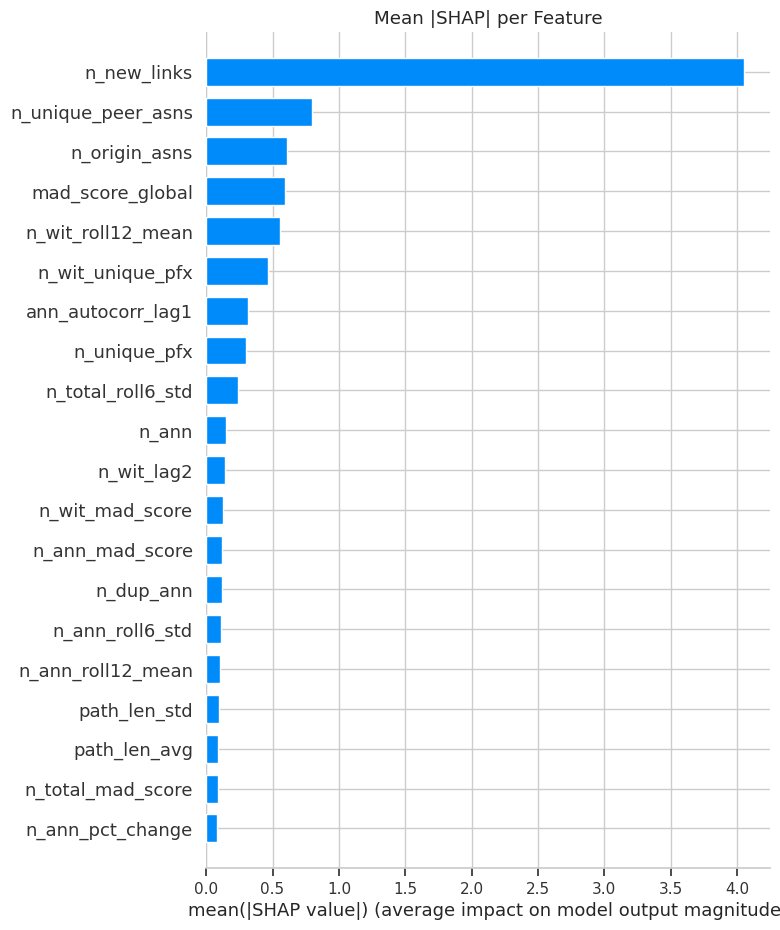

Top 20 features by mean |SHAP|:
           feature  mean_abs_shap
       n_new_links       4.049261
n_unique_peer_asns       0.796418
     n_origin_asns       0.605896
  mad_score_global       0.597245
 n_wit_roll12_mean       0.554024
  n_wit_unique_pfx       0.462697
 ann_autocorr_lag1       0.316871
      n_unique_pfx       0.299380
 n_total_roll6_std       0.242971
             n_ann       0.148566
        n_wit_lag2       0.144614
   n_wit_mad_score       0.126617
   n_ann_mad_score       0.119383
         n_dup_ann       0.119253
   n_ann_roll6_std       0.112409
 n_ann_roll12_mean       0.105717
      path_len_std       0.097353
      path_len_avg       0.091792
 n_total_mad_score       0.089999
  n_ann_pct_change       0.082773


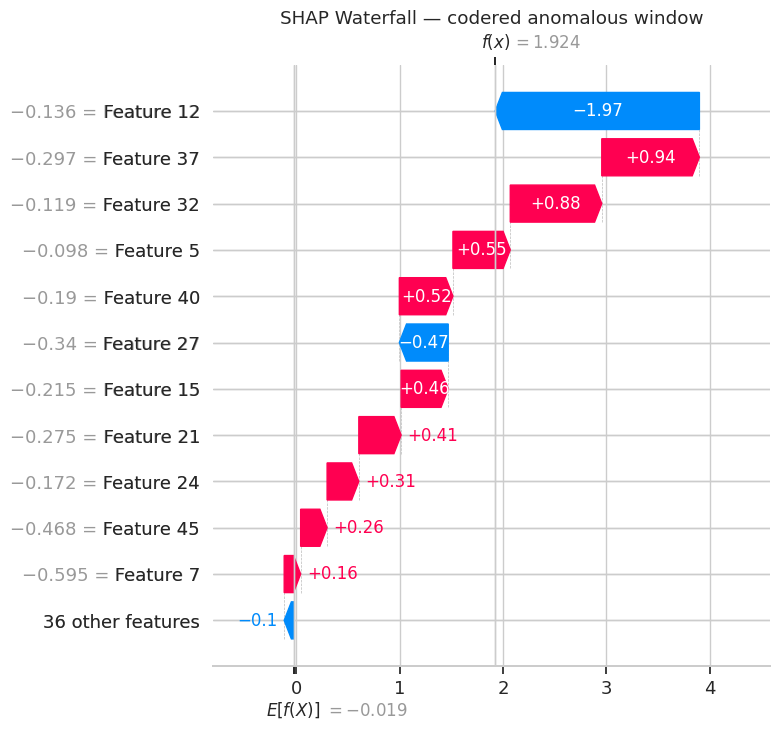

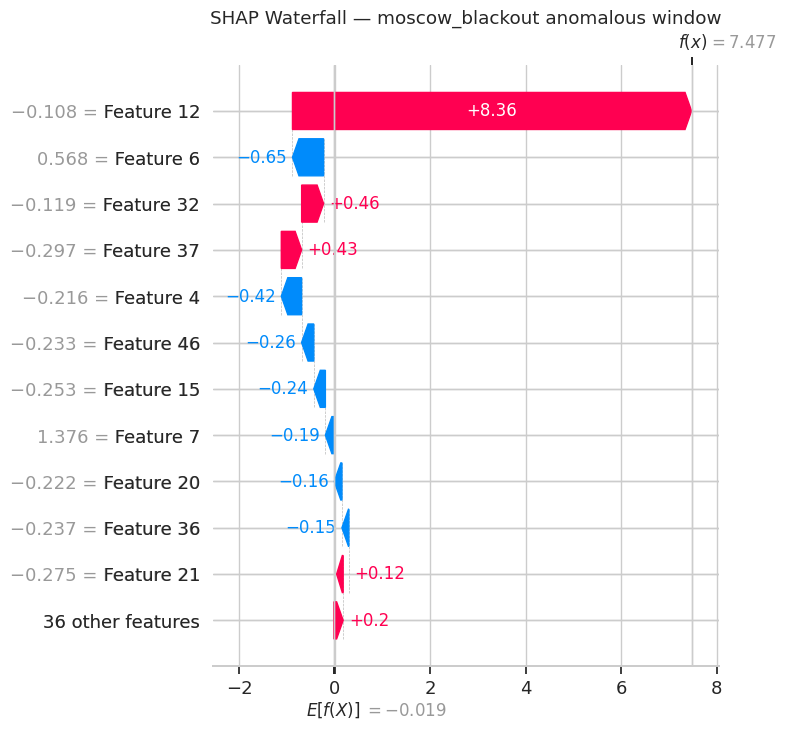

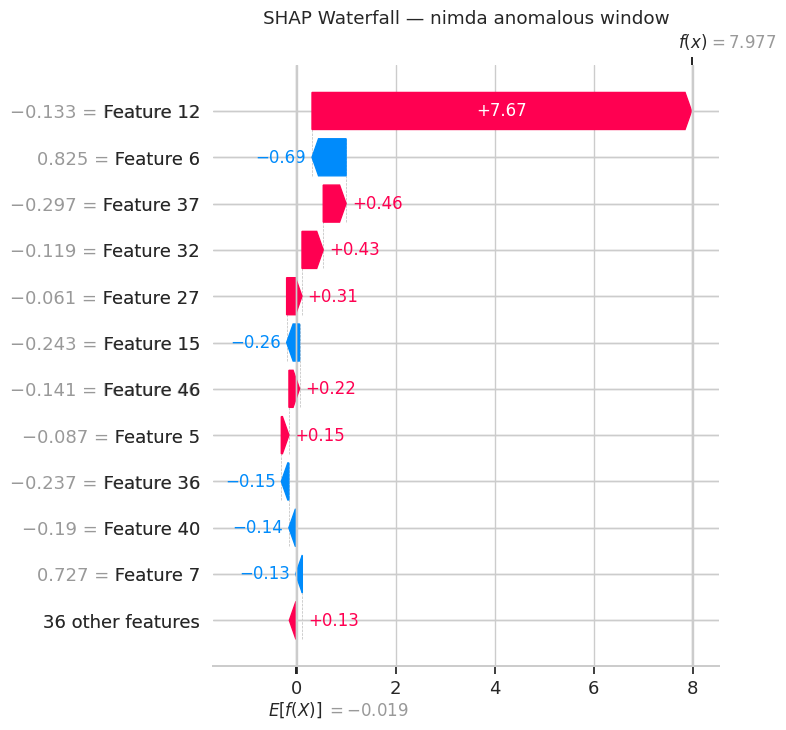

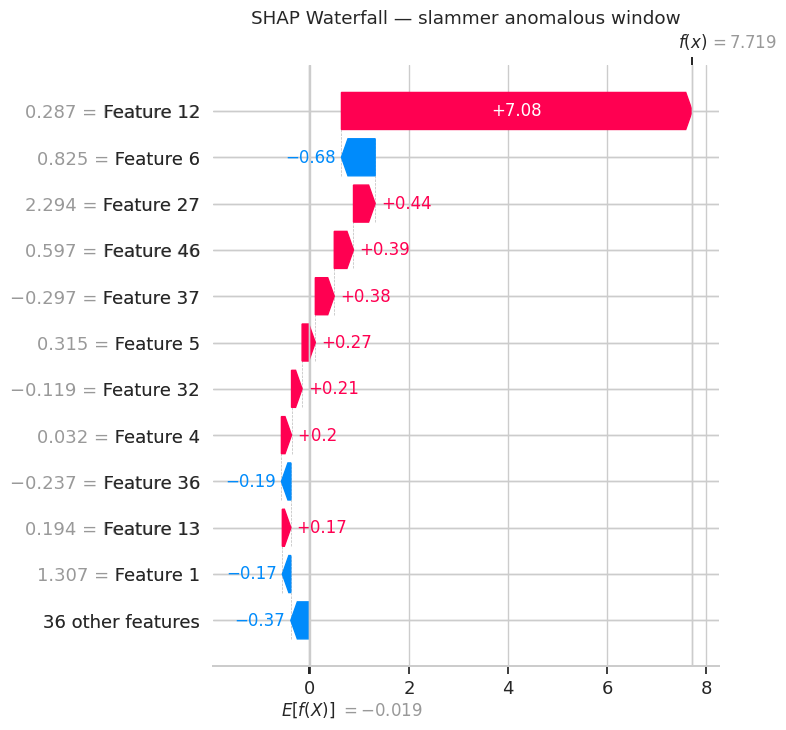

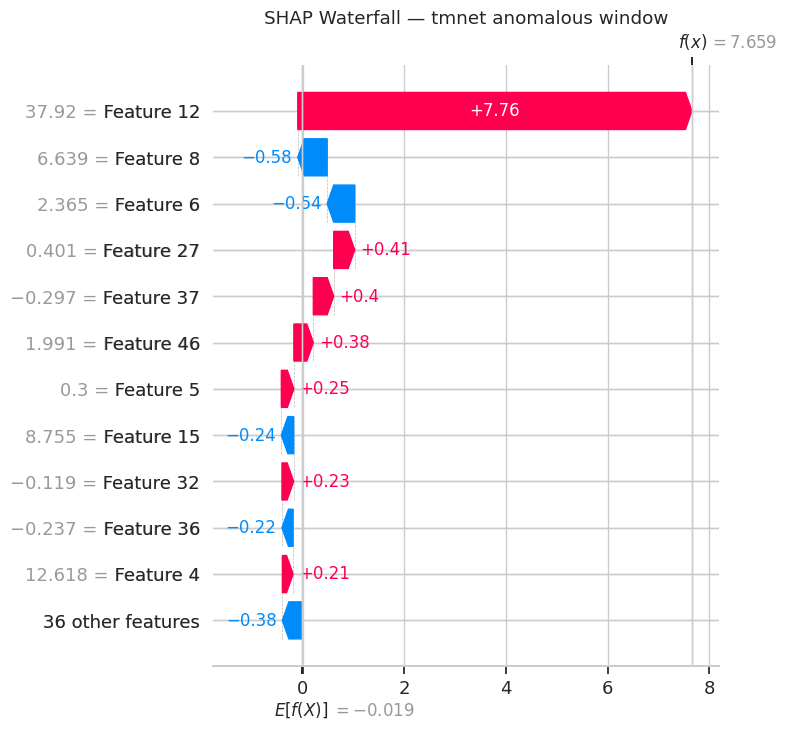

In [19]:
# ── Retrain XGBoost on full balanced data for SHAP ────────────────────────────
xgb_shap = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=spw, eval_metric='logloss',
    tree_method='hist',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    random_state=SEED, verbosity=0
)
xgb_shap.fit(X_scaled, y_bin)

explainer = shap.TreeExplainer(xgb_shap)

# Sample for speed (2000 rows max)
n_sample = min(2000, len(X_scaled))
idx_s    = np.random.choice(len(X_scaled), n_sample, replace=False)
shap_vals = explainer.shap_values(X_scaled[idx_s])

# ── Summary plot ──────────────────────────────────────────────────────────────
plt.figure(figsize=(11, 9))
shap.summary_plot(shap_vals, X_scaled[idx_s],
                  feature_names=FEATURE_COLS, max_display=25, show=False)
plt.title('SHAP Feature Importance — XGBoost (Binary BGP Anomaly Detection)')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=110, bbox_inches='tight')
plt.show()

# ── Bar plot ──────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_scaled[idx_s],
                  feature_names=FEATURE_COLS, plot_type='bar',
                  max_display=20, show=False)
plt.title('Mean |SHAP| per Feature')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=110, bbox_inches='tight')
plt.show()

# ── Feature importance table ──────────────────────────────────────────────────
shap_mean = np.abs(shap_vals).mean(axis=0)
shap_df   = pd.DataFrame({'feature': FEATURE_COLS, 'mean_abs_shap': shap_mean})
shap_df   = shap_df.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
shap_df.to_csv('shap_feature_importance.csv', index=False)
print('Top 20 features by mean |SHAP|:')
print(shap_df.head(20).to_string(index=False))

# ── Per-event waterfall (one anomalous window per event) ──────────────────────
df_bal_reset = df_balanced.reset_index(drop=True)
for ev in EVENTS_LIST:
    mask = (df_bal_reset['event'] == ev) & (df_bal_reset['label_int'] == 1)
    if mask.sum() == 0: continue
    row_i = mask.idxmax()
    if row_i >= len(X_scaled): continue
    row_e = explainer(X_scaled[[row_i]], check_additivity=False)
    plt.figure(figsize=(13, 4))
    shap.waterfall_plot(row_e[0], max_display=12, show=False)
    plt.title(f'SHAP Waterfall — {ev} anomalous window')
    plt.tight_layout()
    plt.savefig(f'shap_waterfall_{ev}.png', dpi=110, bbox_inches='tight')
    plt.show()

## Cell 14 — ROC / PR Curves

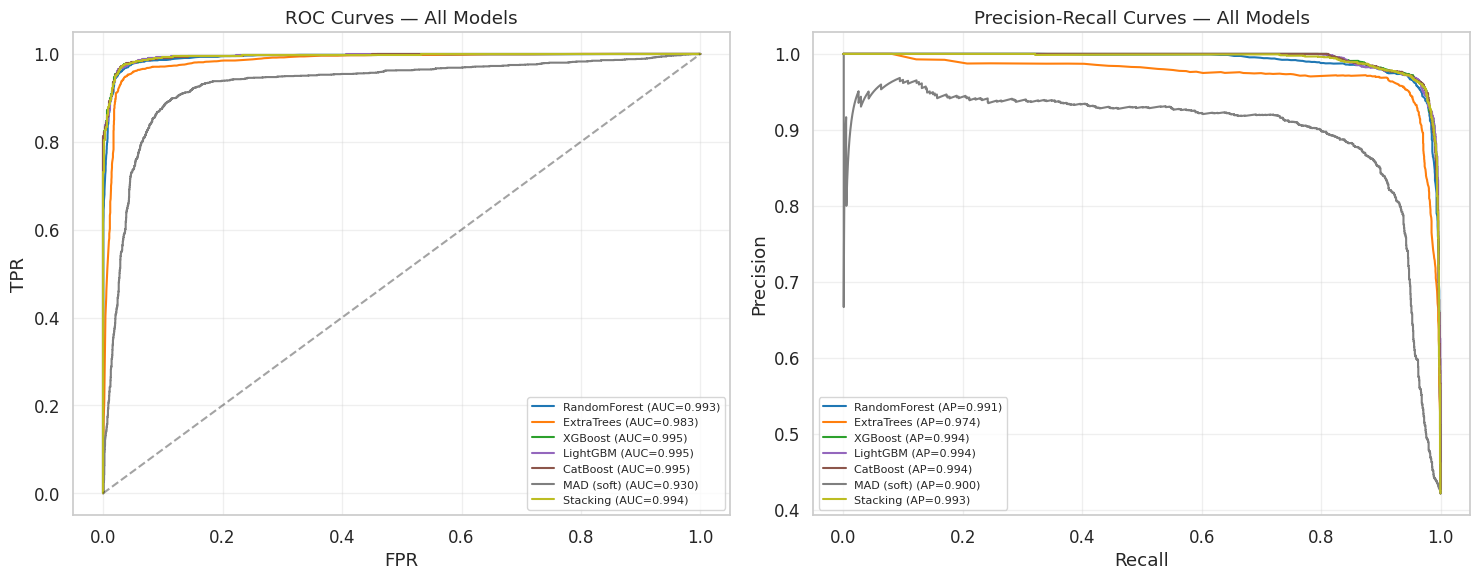

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ax_roc, ax_pr = axes
colors = plt.cm.tab10(np.linspace(0, 1, 8))

plot_items = []

# ML models (window-level)
for name in ML_MODELS_BIN.keys():
    if name in ml_proba_bin:
        plot_items.append((name, ml_proba_bin[name][:, 1], y_bin))

# MAD soft score (normalised)
mad_raw  = df_balanced['mad_score_global'].values
mad_norm = (mad_raw - mad_raw.min()) / (mad_raw.max() - mad_raw.min() + 1e-9)
plot_items.append(('MAD (soft)', mad_norm, y_bin))

# Stacking
plot_items.append(('Stacking', meta_proba[:, 1], y_meta))

for (name, prob, y_true), color in zip(plot_items, colors):
    fpr, tpr, _ = roc_curve(y_true, prob)
    roc_auc_v   = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_v:.3f})', color=color)

    prec, rec, _ = precision_recall_curve(y_true, prob)
    ap            = average_precision_score(y_true, prob)
    ax_pr.plot(rec, prec, label=f'{name} (AP={ap:.3f})', color=color)

ax_roc.plot([0,1],[0,1],'k--',alpha=0.4)
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR')
ax_roc.set_title('ROC Curves — All Models')
ax_roc.legend(fontsize=8); ax_roc.grid(True, alpha=0.3)

ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curves — All Models')
ax_pr.legend(fontsize=8); ax_pr.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=110, bbox_inches='tight')
plt.show()

## Cell 15 — Per-Event Timeline Visualisation

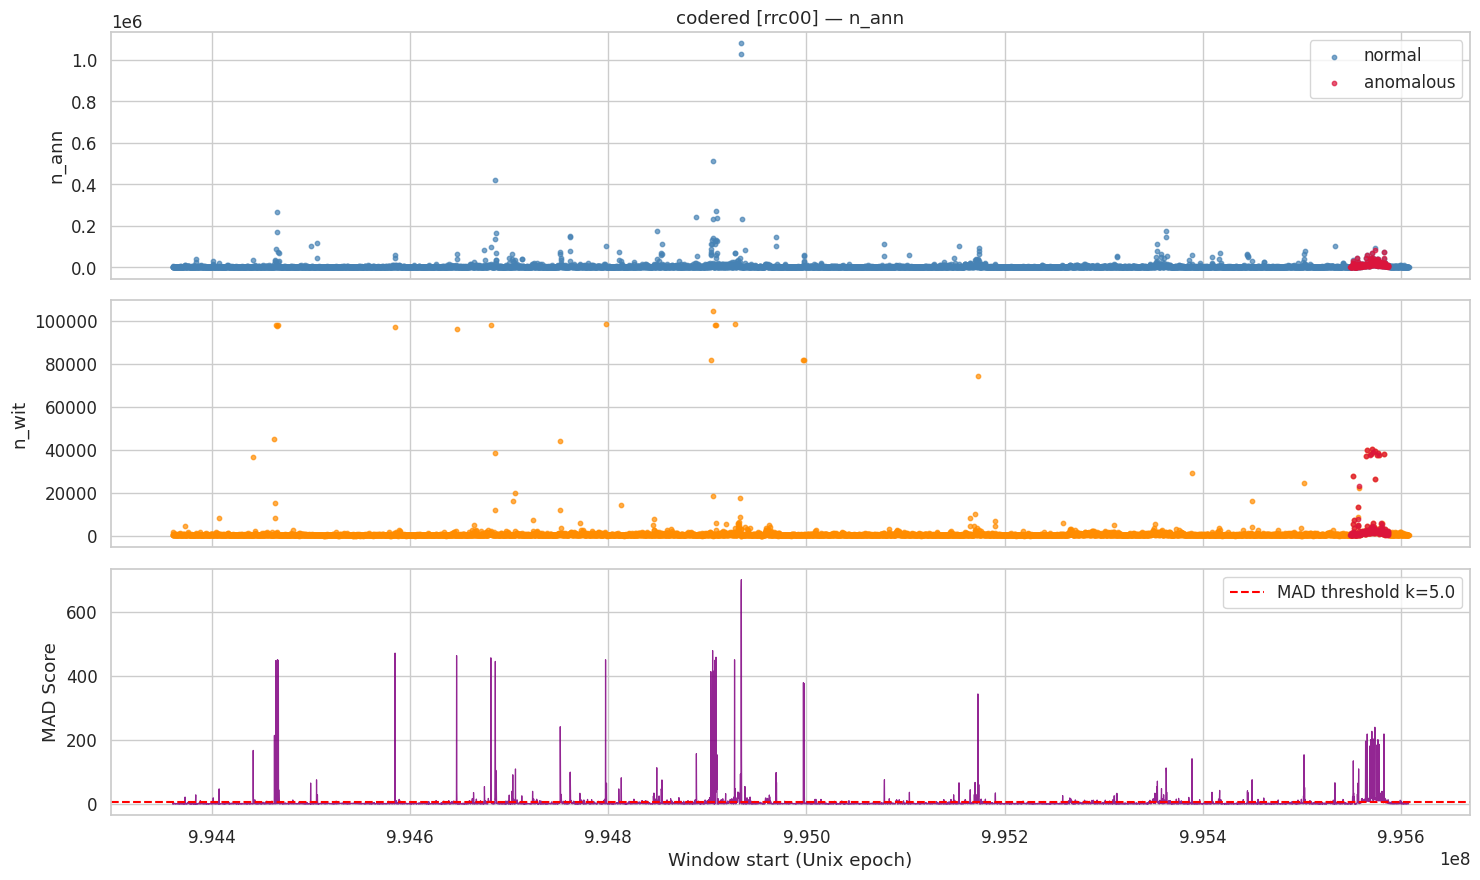

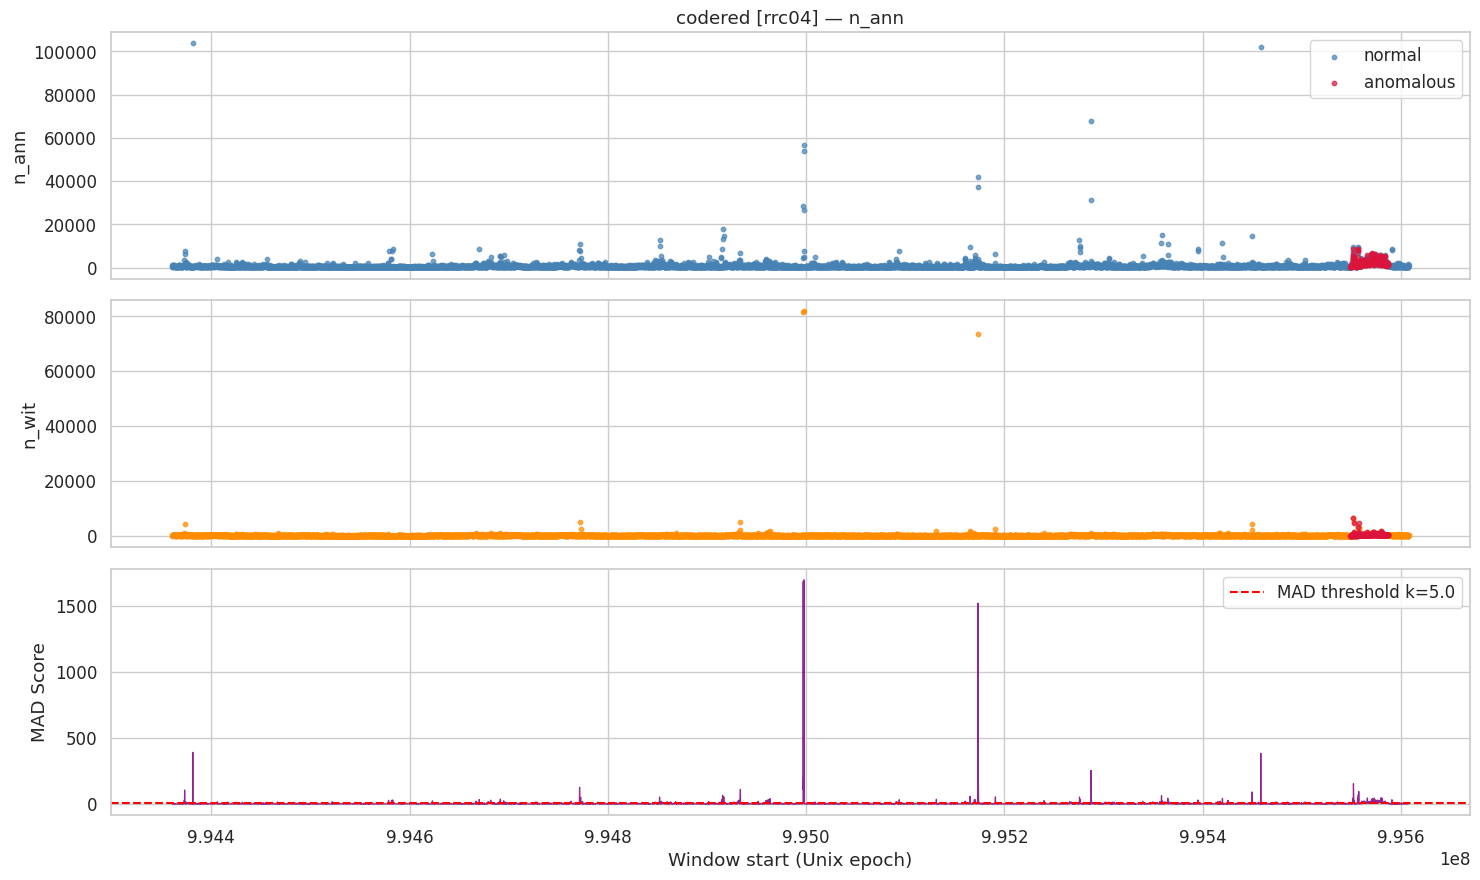

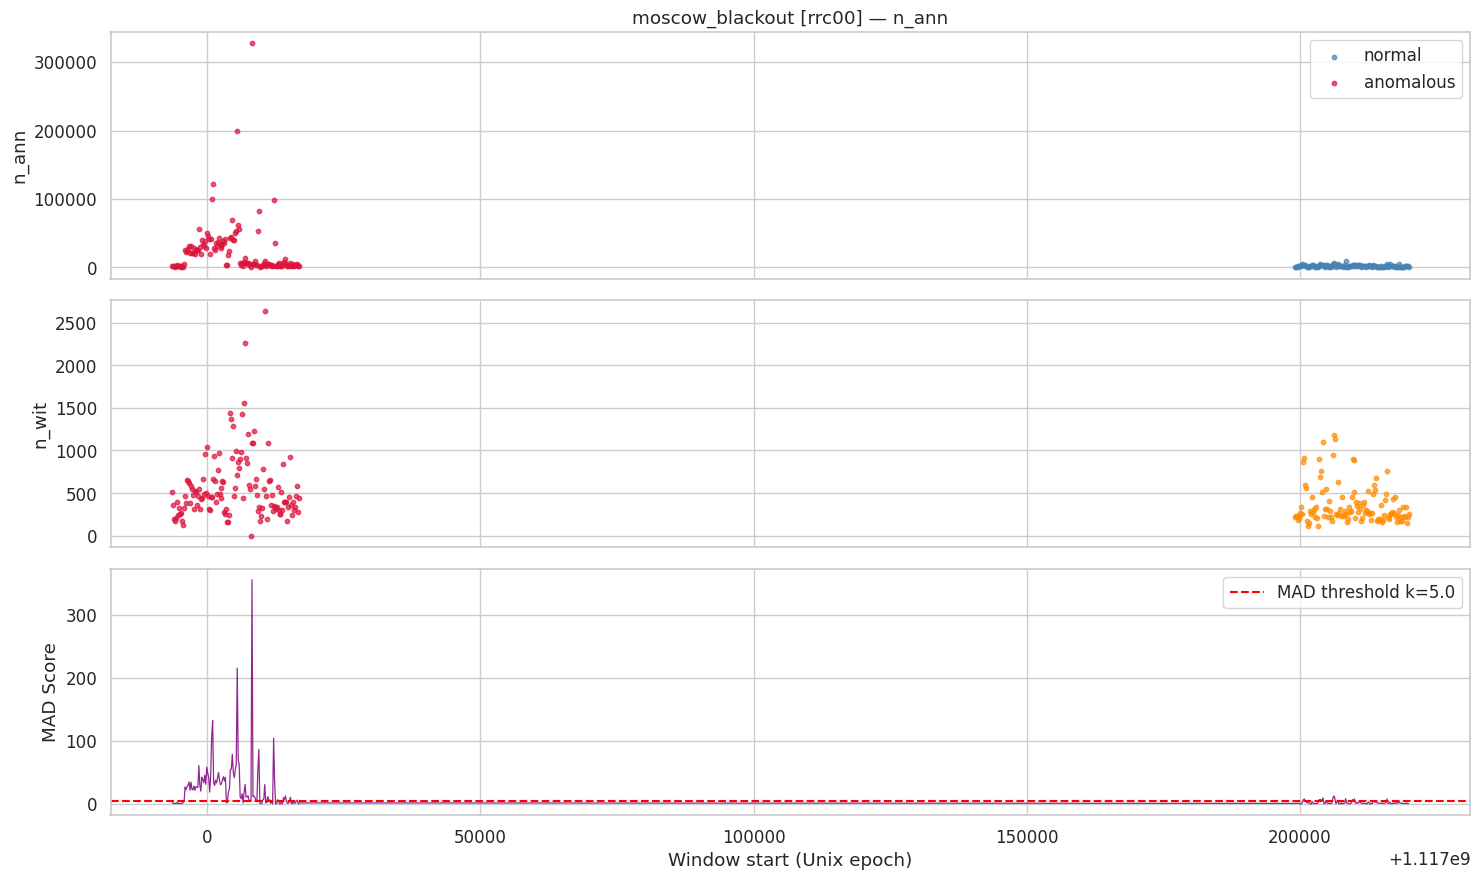

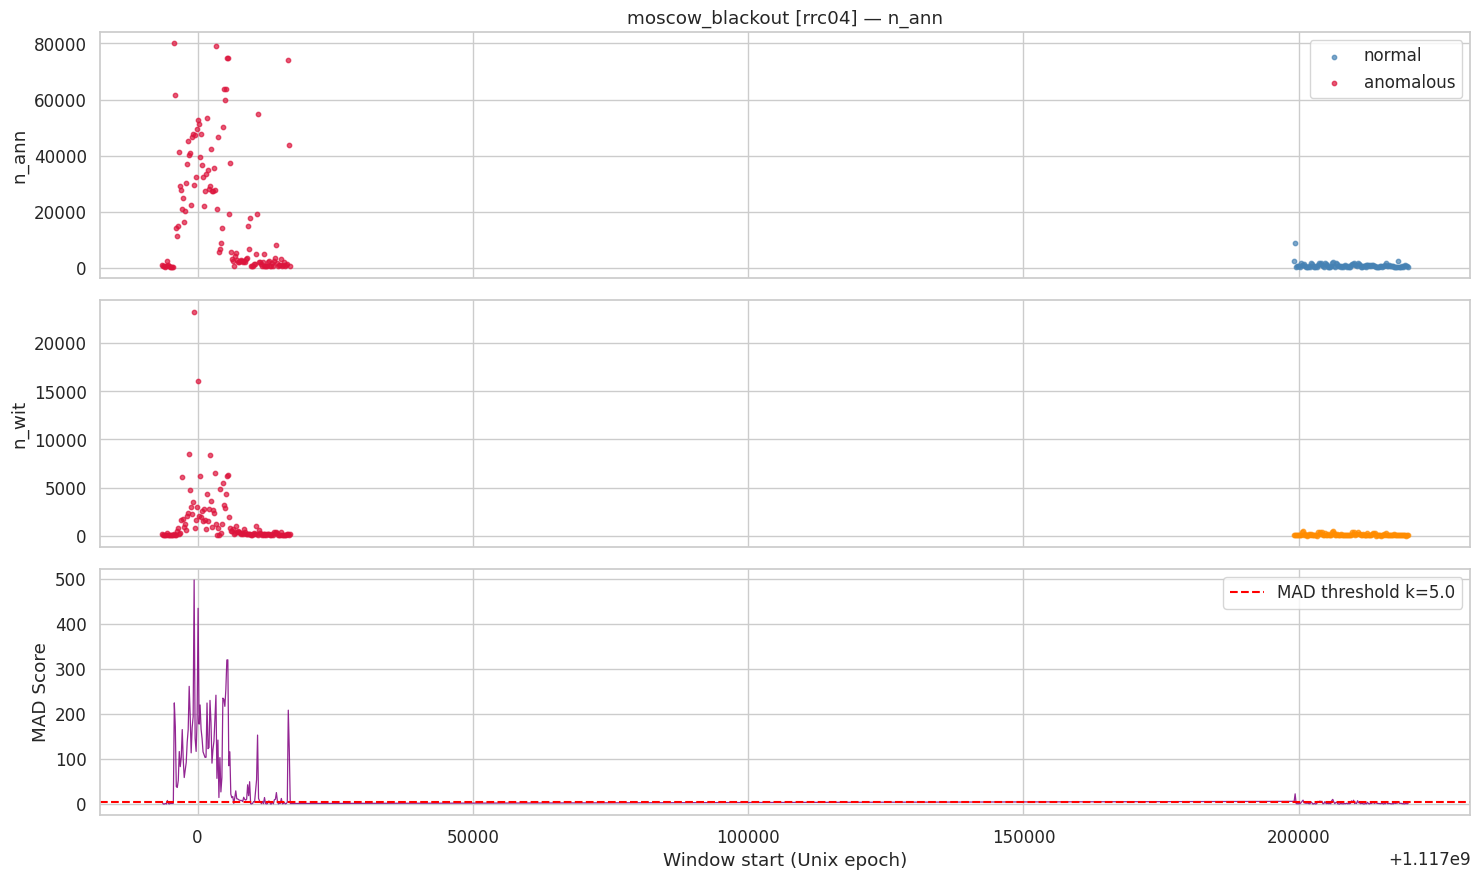

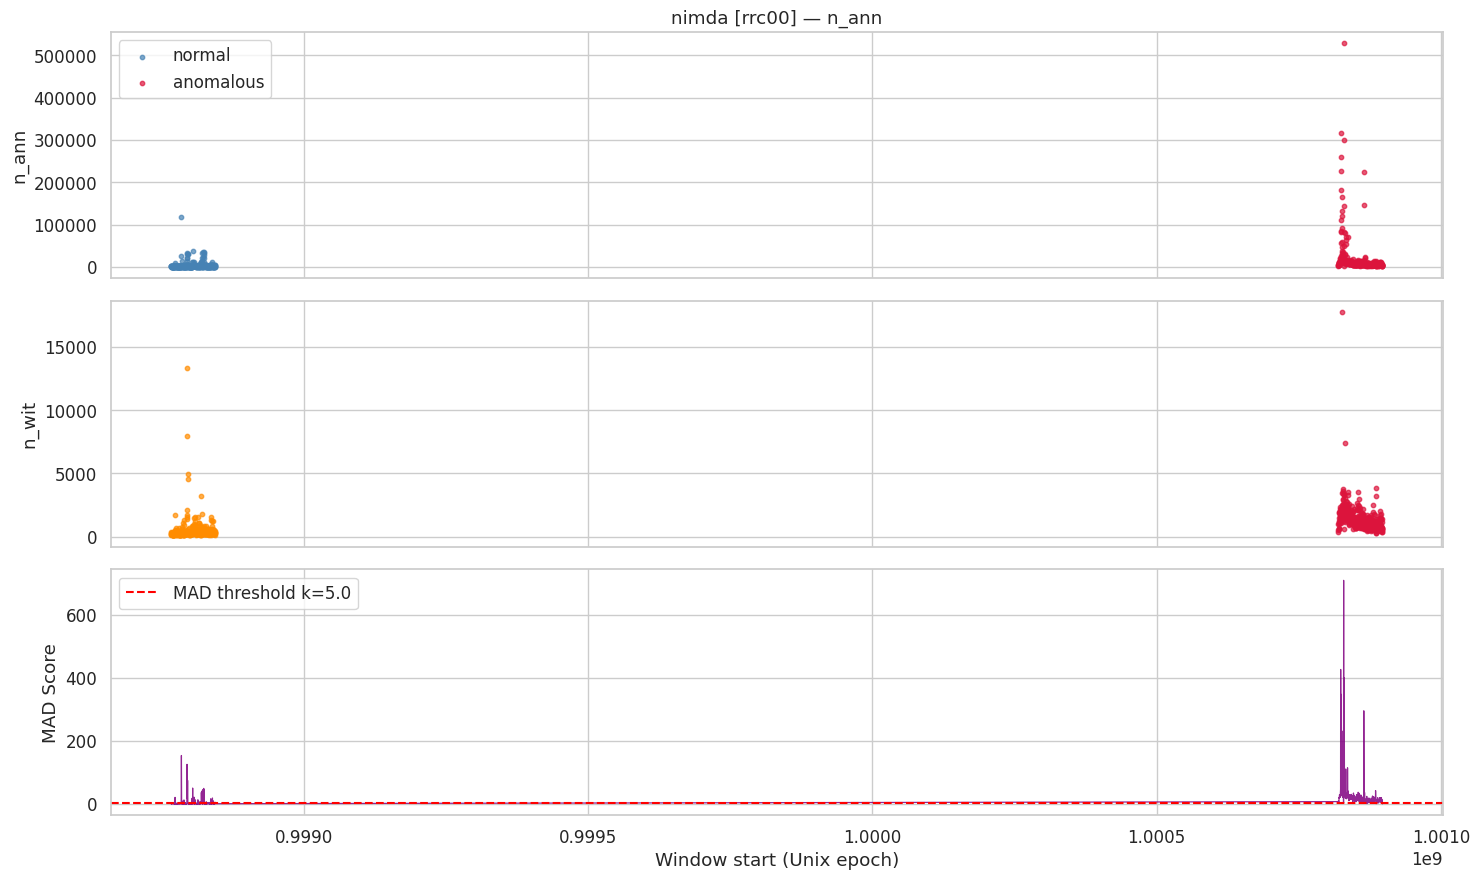

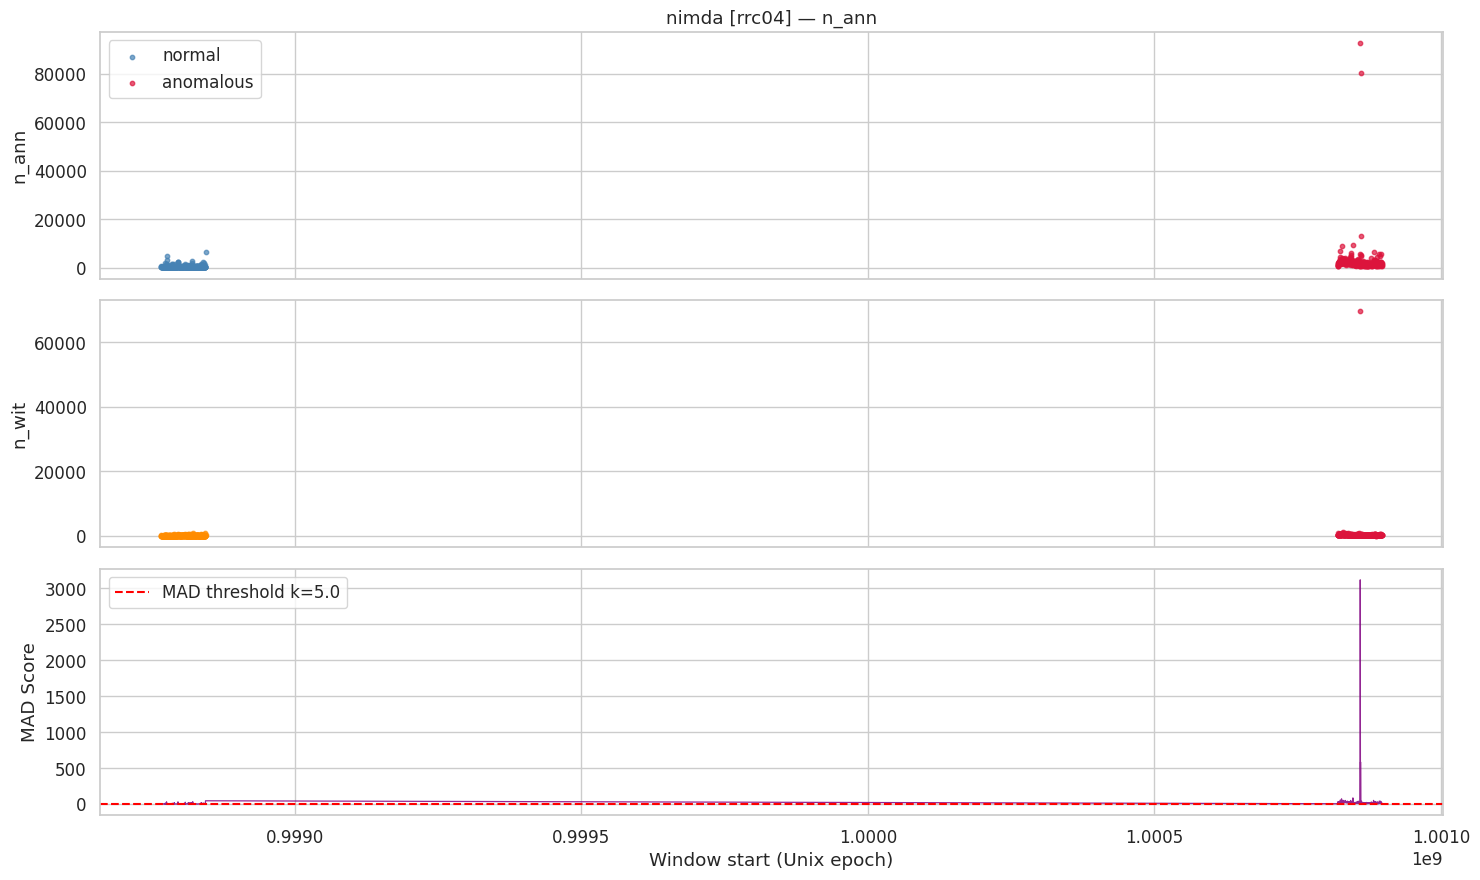

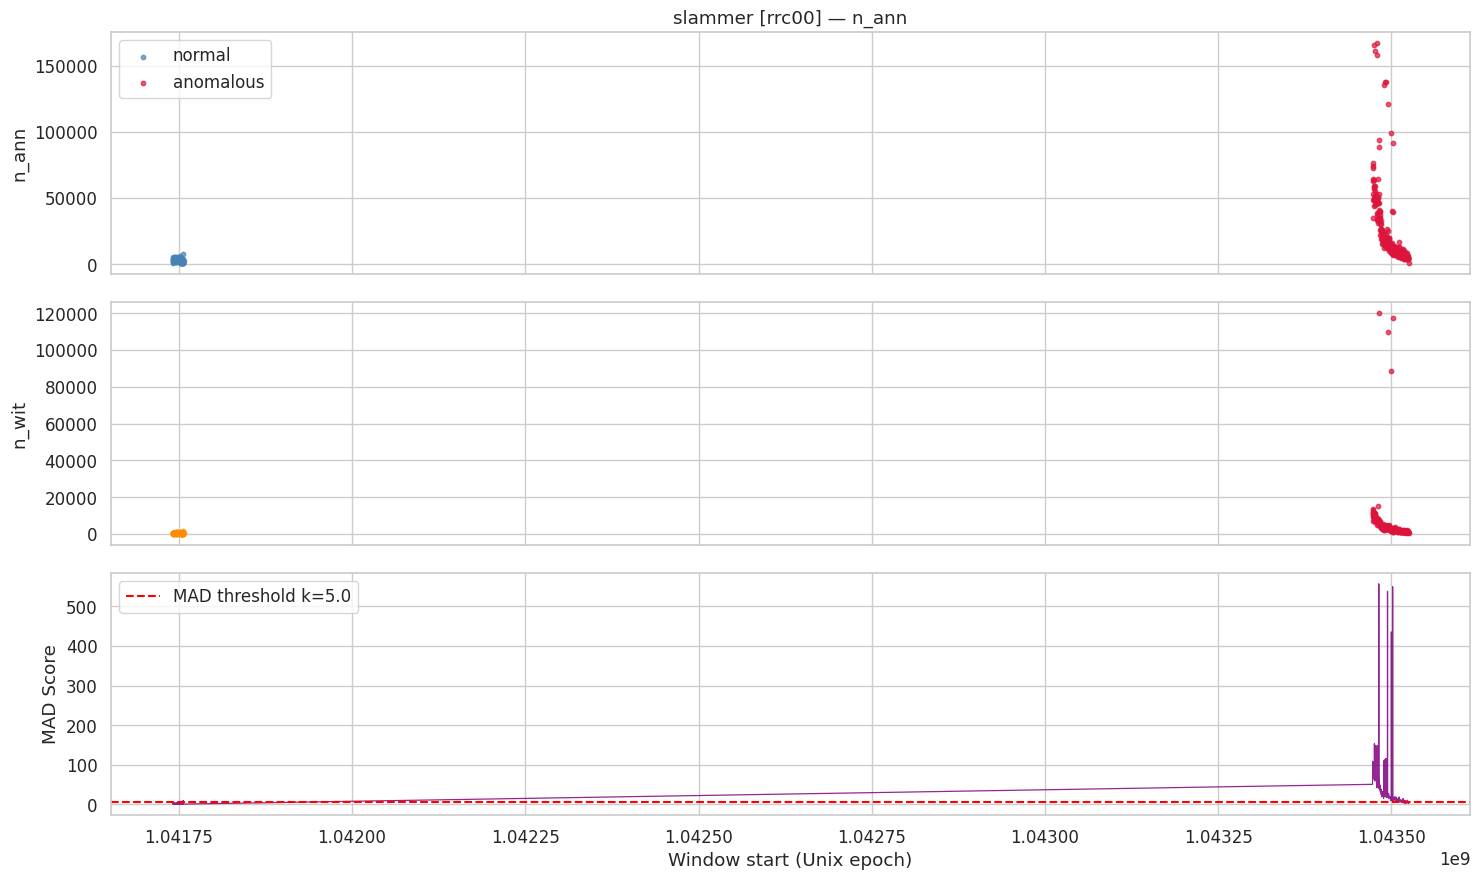

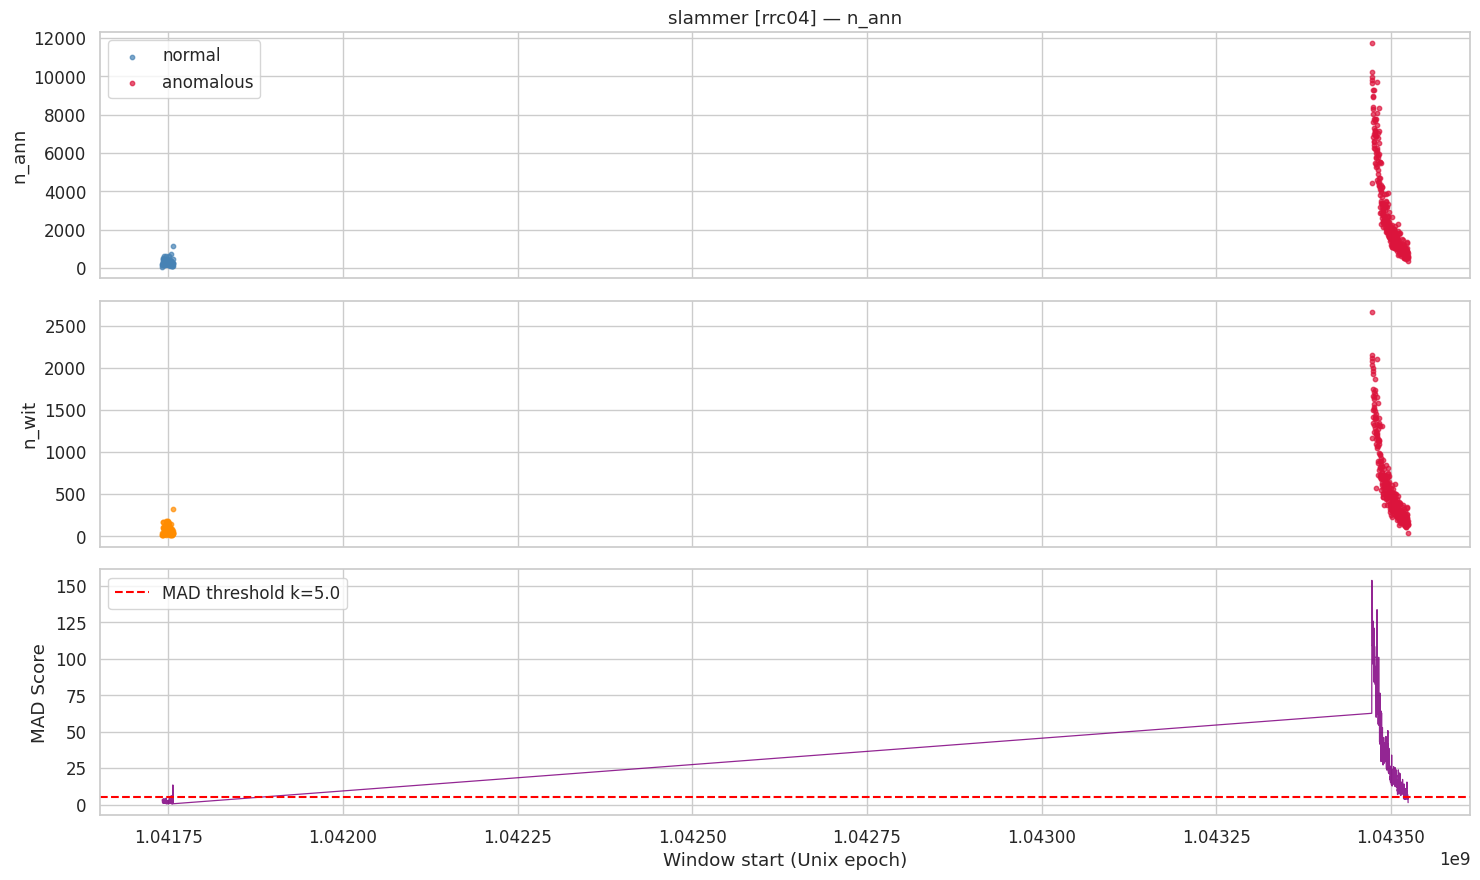

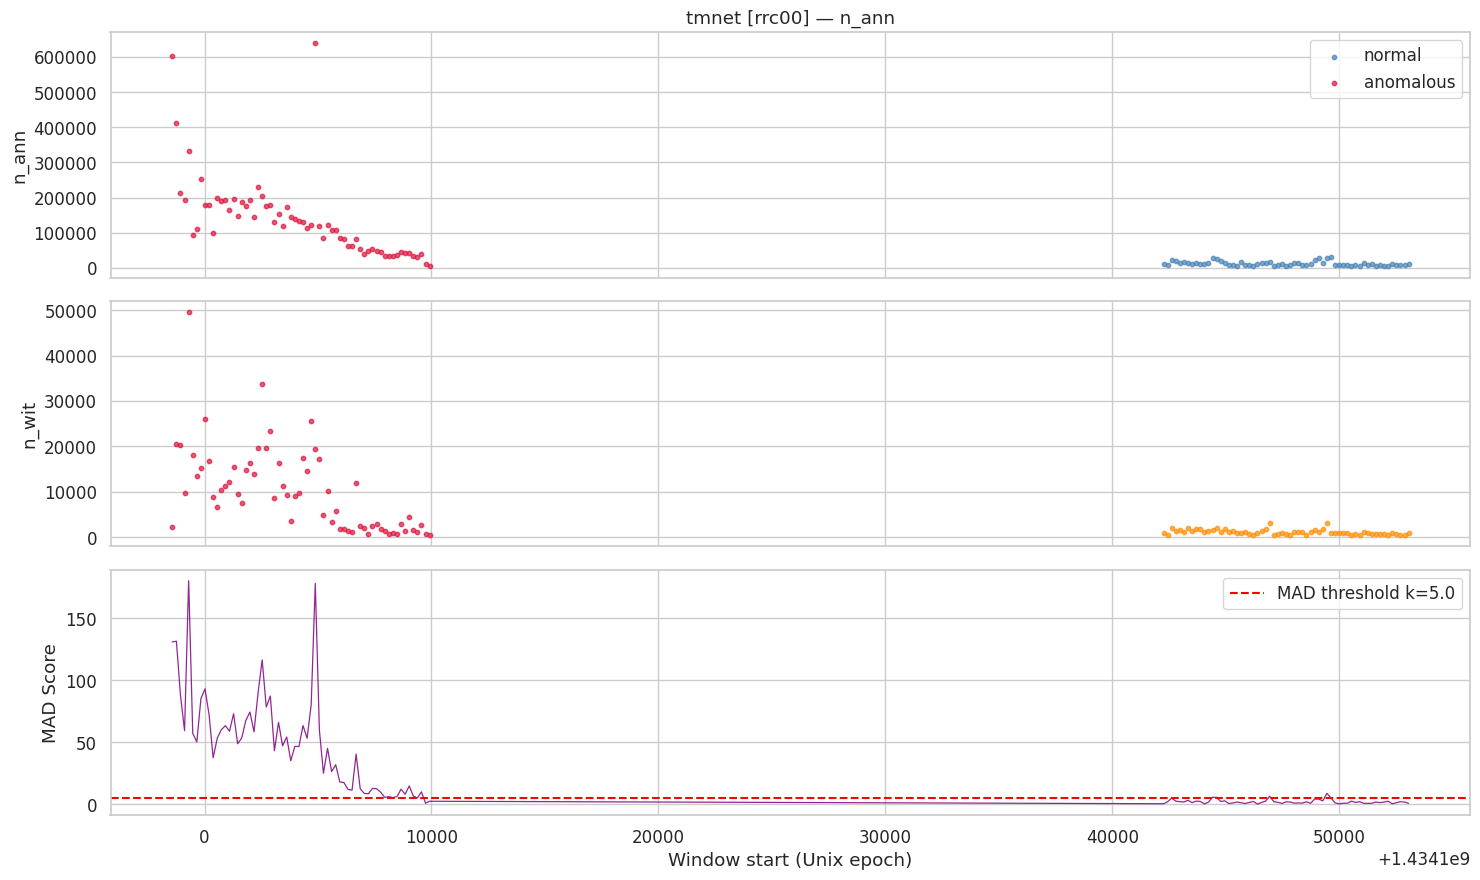

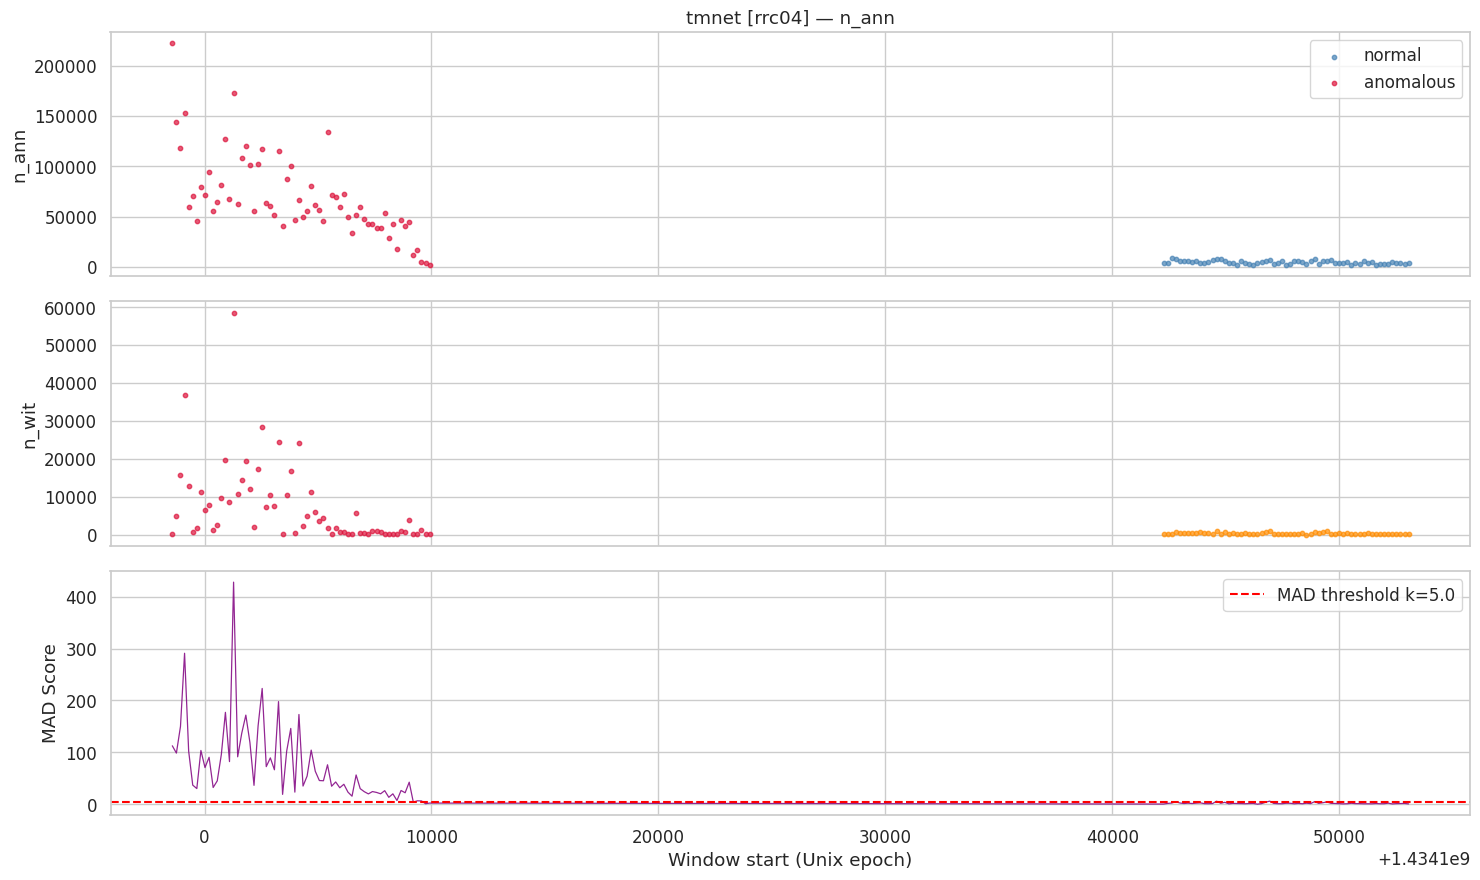

In [21]:
# Use FULL (unbalanced) dataset for timeline visualisation so anomalous
# and normal periods appear in their real temporal positions.

def plot_event_timeline(df_in, event_name, collector='rrc00',
                         feat='n_ann', mad_k=5.0):
    sub = df_in[(df_in['event'] == event_name) &
                (df_in['collector'] == collector)].sort_values('window_start')
    if feat not in sub.columns or len(sub) == 0:
        return

    fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)

    # Panel 1: raw feature
    for lbl, grp in sub.groupby('label_int'):
        color = 'crimson' if lbl == 1 else 'steelblue'
        axes[0].scatter(grp['window_start'], grp[feat],
                        c=color, s=10, alpha=0.7,
                        label='anomalous' if lbl==1 else 'normal')
    axes[0].set_ylabel(feat); axes[0].legend()
    axes[0].set_title(f'{event_name} [{collector}] — {feat}')

    # Panel 2: withdrawal count
    if 'n_wit' in sub.columns:
        for lbl, grp in sub.groupby('label_int'):
            color = 'crimson' if lbl == 1 else 'darkorange'
            axes[1].scatter(grp['window_start'], grp['n_wit'],
                            c=color, s=10, alpha=0.7)
        axes[1].set_ylabel('n_wit')

    # Panel 3: MAD score
    if 'mad_score_global' in sub.columns:
        axes[2].plot(sub['window_start'], sub['mad_score_global'],
                     color='purple', linewidth=0.9, alpha=0.85)
        axes[2].axhline(mad_k, color='red', linestyle='--',
                         label=f'MAD threshold k={mad_k}')
        axes[2].set_ylabel('MAD Score'); axes[2].legend()
    axes[2].set_xlabel('Window start (Unix epoch)')

    plt.tight_layout()
    plt.savefig(f'timeline_{event_name}_{collector}.png',
                dpi=110, bbox_inches='tight')
    plt.show()


for ev in EVENTS_LIST:
    for col in ['rrc00', 'rrc04']:
        plot_event_timeline(df, ev, collector=col, feat='n_ann', mad_k=MAD_K)

## Cell 16 — Final Results Summary Table

FINAL RESULTS SUMMARY
             Model  F1-macro  F1-std  Note
        BiLSTM_bin    0.9918  0.0052      
         BiGRU_bin    0.9888  0.0038      
    CatBoost_multi    0.9703  0.0066      
     XGBoost_multi    0.9702  0.0092      
    LightGBM_multi    0.9696  0.0062      
      LightGBM_bin    0.9689  0.0049      
       XGBoost_bin    0.9682  0.0042      
      Stacking_bin    0.9674  0.0042      
      CatBoost_bin    0.9668  0.0049      
RandomForest_multi    0.9664  0.0079      
  RandomForest_bin    0.9645  0.0055      
    ExtraTrees_bin    0.9545  0.0095      
  ExtraTrees_multi    0.9537  0.0081      
     GraphSAGE_bin    0.9243  0.0239      
               MAD    0.8096  0.0000 k=7.0


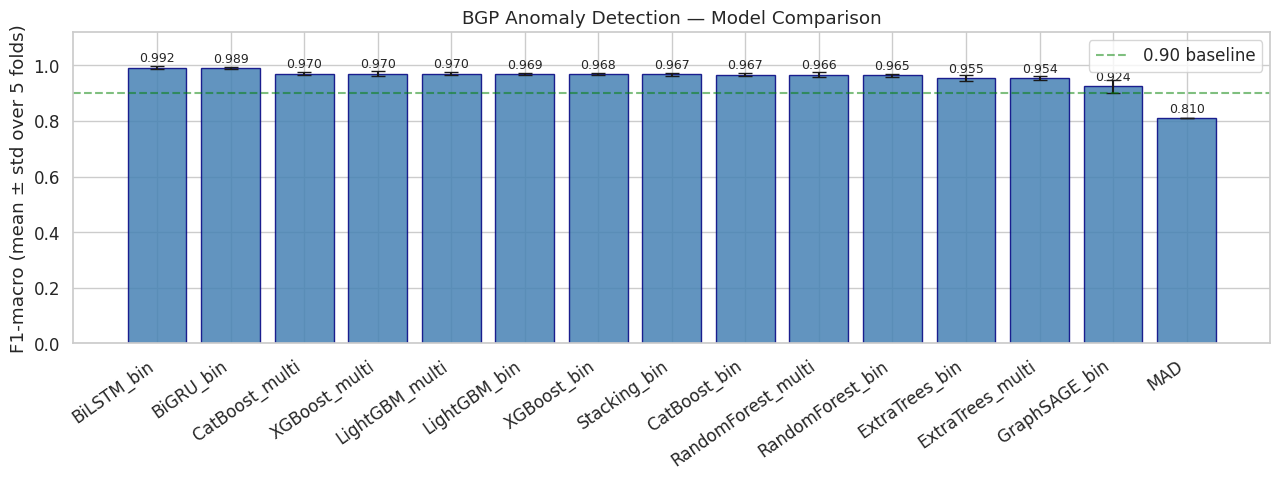


Cross-Event Generalisation (F1-macro):
 Held-out Event     F1  Precision  Recall
        codered 0.5014     0.2667  0.0094
moscow_blackout 0.9980     1.0000  0.9962
          nimda 0.9849     0.9872  0.9826
        slammer 1.0000     1.0000  1.0000
          tmnet 0.8901     0.8258  1.0000


In [22]:
print('='*65)
print('FINAL RESULTS SUMMARY')
print('='*65)

rows = []
for model_name, metrics in RESULTS.items():
    if not isinstance(metrics, dict): continue
    if 'f1_macro' not in metrics:     continue
    rows.append({
        'Model':    model_name,
        'F1-macro': round(metrics['f1_macro'], 4),
        'F1-std':   round(metrics.get('f1_std', 0), 4),
        'Note':     metrics.get('note', ''),
    })

df_results = pd.DataFrame(rows).sort_values('F1-macro', ascending=False)
print(df_results.to_string(index=False))
df_results.to_csv('bgp_model_results.csv', index=False)

# ── Bar chart ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
colors_bar = ['#D65F5F' if 'cross' not in n.lower() else '#6ACC65'
              for n in df_results['Model']]
bars = ax.bar(df_results['Model'], df_results['F1-macro'],
              yerr=df_results['F1-std'], capsize=5,
              color='steelblue', edgecolor='navy', alpha=0.85)
ax.set_ylim(0, 1.12)
ax.set_ylabel('F1-macro (mean ± std over 5 folds)')
ax.set_title('BGP Anomaly Detection — Model Comparison')
ax.set_xticklabels(df_results['Model'], rotation=35, ha='right')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9)
ax.axhline(0.9, color='green', linestyle='--', alpha=0.5, label='0.90 baseline')
ax.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=110, bbox_inches='tight')
plt.show()

# ── Cross-event table ─────────────────────────────────────────────────────────
if 'cross_event_XGBoost' in RESULTS:
    print('\nCross-Event Generalisation (F1-macro):')
    ce = RESULTS['cross_event_XGBoost']
    ce_df = pd.DataFrame([
        {'Held-out Event': ev, 'F1': round(v['f1'],4),
         'Precision': round(v['precision'],4), 'Recall': round(v['recall'],4)}
        for ev, v in ce.items()
    ])
    print(ce_df.to_string(index=False))
    ce_df.to_csv('cross_event_results.csv', index=False)

## Cell 17 — Save All Artifacts & Download

In [23]:
import shutil

# ── Save scalers ──────────────────────────────────────────────────────────────
with open('scaler_main.pkl', 'wb') as f: pickle.dump(scaler,   f)
with open('scaler_meta.pkl', 'wb') as f: pickle.dump(meta_sc,  f)

# ── Save feature column list ──────────────────────────────────────────────────
with open('feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f, indent=2)

# ── Retrain & save best ML model on full balanced data ────────────────────────
xgb_final = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=spw, eval_metric='logloss',
    tree_method='hist',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    random_state=SEED, verbosity=0
)
xgb_final.fit(X_scaled, y_bin)
xgb_final.save_model('bgp_xgboost_final.json')

rf_final = RandomForestClassifier(
    n_estimators=300, class_weight='balanced', n_jobs=-1, random_state=SEED
)
rf_final.fit(X_scaled, y_bin)
with open('bgp_rf_final.pkl', 'wb') as f: pickle.dump(rf_final, f)

# ── List artifacts ────────────────────────────────────────────────────────────
artifact_files = [
    'scaler_main.pkl', 'scaler_meta.pkl', 'feature_cols.json',
    'bgp_xgboost_final.json', 'bgp_rf_final.pkl',
    'bgp_lstm.pt', 'bgp_gru.pt', 'bgp_gnn.pt',
    'bgp_model_results.csv', 'cross_event_results.csv',
    'shap_feature_importance.csv',
]
print('Saved artifacts:')
for f in artifact_files:
    exists = os.path.exists(f)
    size   = os.path.getsize(f)/1024 if exists else 0
    print(f'  {"✓" if exists else "✗"} {f:40s} {size:7.1f} KB')

# ── Zip & download ────────────────────────────────────────────────────────────
os.makedirs('bgp_outputs', exist_ok=True)
for f in artifact_files:
    if os.path.exists(f):
        shutil.copy(f, f'bgp_outputs/{f}')

# Copy all PNG plots
import glob
for png in glob.glob('*.png'):
    shutil.copy(png, f'bgp_outputs/{png}')

shutil.make_archive('bgp_anomaly_outputs', 'zip', 'bgp_outputs')
print('\n→ bgp_anomaly_outputs.zip ready')

from google.colab import files
files.download('bgp_anomaly_outputs.zip')

Saved artifacts:
  ✓ scaler_main.pkl                              1.5 KB
  ✓ scaler_meta.pkl                              0.7 KB
  ✓ feature_cols.json                            0.9 KB
  ✓ bgp_xgboost_final.json                     825.4 KB
  ✓ bgp_rf_final.pkl                          9875.9 KB
  ✓ bgp_lstm.pt                               2329.9 KB
  ✓ bgp_gru.pt                                1766.3 KB
  ✓ bgp_gnn.pt                                 267.7 KB
  ✓ bgp_model_results.csv                        0.4 KB
  ✓ cross_event_results.csv                      0.2 KB
  ✓ shap_feature_importance.csv                  1.2 KB

→ bgp_anomaly_outputs.zip ready


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Pipeline Summary

| Stage | Model | Type | Data Used |
|---|---|---|---|
| 1 | MAD Pre-filter (k=5) | Statistical | Full dataset (17,508 windows) |
| 2a | Random Forest | Supervised ML | Balanced (cap 4× per event) |
| 2a | Extra Trees | Supervised ML | Balanced |
| 2a | XGBoost | Supervised ML | Balanced + scale_pos_weight |
| 2a | LightGBM | Supervised ML | Balanced + is_unbalance |
| 2a | CatBoost | Supervised ML | Balanced + auto_class_weights |
| 2b | Bi-LSTM (attention) | Deep Learning | Sequences (SEQ_LEN=20, stride=5) |
| 2b | Bi-GRU (attention) | Deep Learning | Sequences |
| 2c | GraphSAGE | Graph DL | Chain graphs (group=10, stride=5) |
| 3 | Stacking (LR meta) | Ensemble | OOF proba from ML models |
| — | SHAP | Explainability | XGBoost on balanced data |
| — | Cross-event (LOEO) | Generalisation | Full dataset |

**Key dataset facts:**  
- 17,508 total windows | 47 features | MAD threshold k=5  
- Imbalance ratio 6.7:1 → handled with BorderlineSMOTE + class weights  
- codered_normal dominance (79%) → capped at 4× anomalous count per event
